# Full-Text Test Run: Coding the Integration Ladder, and Checking the Evidence

### Applying the Stage 3 deep coding scheme to the open-access full texts the abstract stage carried forward, once per model, with three providers

**Stijn Van Severen · Christopher Eccleston · Annick De Paepe · Maya Braun · Julie Dendauw · Jose Luis Socorro Cumplido · Geert Crombez**
Ghent University · OSF registration [10.17605/OSF.IO/T4FAM](https://doi.org/10.17605/OSF.IO/T4FAM)

---

This notebook is the **second half** of the chain that
[`01_abstractlevel_testrun.ipynb`](01_abstractlevel_testrun.ipynb) starts. That notebook coded
100 PubMed abstracts with three models and produced a consensus candidate set. This one
retrieves the open-access full texts of those candidates and applies the **Stage 3 deep coding
scheme** to each of them with the same three models.

The two stages differ in purpose, not only in depth:

| | Abstract level (scheme 2) | Full text (scheme 3) |
| --- | --- | --- |
| Reads | title and abstract | the whole article |
| Mainly does | routing and relevance filtering | graded measurement of coverage and integration |
| Core output | a provisional signal | a graded ladder with a quoted passage behind every rung |
| Answers | which records are worth reading | does a biopsychosocially labelled review actually integrate the three domains, and how |

> **This is a test run of the instrument, not a finding about the literature.** Three cheap
> models on 47 open-access articles cannot settle what the biopsychosocial literature does.
> What the run can establish is whether the coding scheme is specified tightly enough that
> independent coders converge, and whether the evidence those coders return is real.

**What this notebook does**

1. Sets out the scheme: three coverage ladders, four integration ladders, and six evidence lists.
2. Follows the corpus funnel from 100 abstracts to the coded full texts, accounting for every drop.
3. Shows exactly what one paper's instruction set and coded output look like.
4. Applies the scheme with every model, one paper per request.
5. Checks integrity first: is the grid complete, are the quotes real, is a graded ladder backed by a passage.
6. Quantifies reliability, including an adjacent-agreement rate built for ordered ladders.
7. Renders four multi-panel figures.
8. Compares the coded typology against the typology the rules derive from coverage and integration.
9. Reports the consensus picture, the cost, and what this says to the expert evaluation.

In [1]:
# --- Setup -------------------------------------------------------------------
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Make the package importable even without an editable install.
ROOT = Path.cwd()
while not (ROOT / "src" / "03_pipeline").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src" / "03_pipeline"))

from bps_review.fulltext.analysis.integrity import build_integrity, label_catalog
from bps_review.fulltext.analysis.reliability import build_reliability
from bps_review.fulltext.analysis.semantic import SIMILARITY_THRESHOLD, build_semantic_overlap
from bps_review.fulltext.coding.condense import build_coding_text
from bps_review.fulltext.coding.prompt import LADDERS, build_prompt, prompt_overview
from bps_review.fulltext.coding.runner import load_items, run_fulltext_testrun
from bps_review.fulltext.config import (
    COVERAGE_FIELDS,
    EXTRACTION_SPACES,
    FIELD_LABELS,
    FULLTEXT_MODELS,
    INTEGRATION_FIELDS,
    LIST_FIELDS,
    PRESENCE_FIELDS,
    codings_dir,
    corpus_manifest_json,
    corpus_selection_log_csv,
    figures_dir,
    graph_dir,
    reliability_dir,
)
from bps_review.fulltext.corpus.pmc import load_corpus, load_corpus_records
from bps_review.fulltext.graph_export import export_fulltext_graph
from bps_review.fulltext.publish import build_output_tables, load_run_from_tables, load_run_manifest
from bps_review.fulltext.pipeline import ensure_corpus
from bps_review.fulltext.report import write_fulltext_summary
from bps_review.fulltext.visualization.figures import build_figures

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 175)
print(f"Repository root: {ROOT}")
print("Environment ready.")

Repository root: /Users/stijnvanseveren/PROJECTS/summer_2026/CROMBEZ_MAP/05_BPS_Review_Study
Environment ready.


## 1. What the scheme measures

The review's central claim is that biopsychosocial language is widespread while substantive
three-domain integration is not. The scheme is built to test that claim, so its most
consequential graded fields are **ladders** rather than labels: each one asks how deep something
goes, not whether it is there.

Three coverage ladders, one per domain, plus two more for the lifestyle and spiritual or
existential domains the registration names alongside the triad. Four integration ladders: three
pairwise and one triadic. Every rung has an operational rule that separates it from the rung
below.

The second half of the scheme is extraction rather than grading, and it is what the later
ontology is built from. **Presence is never the answer; the answer is which ones.** Every
biological, social, lifestyle, and existential factor the review names, every psychological
construct with what the review says it means, every relation drawn between constructs, every
framework and instrument, and every passage where the biopsychosocial label does work, each as
its own item with the review's own wording, an anchor onto the project ontology where one fits,
the role it plays, a verbatim quote, and the section it came from.

In [2]:
for name, rungs in LADDERS.items():
    print(f"### {name.replace('_', ' ')}")
    for value, rule in rungs.items():
        print(f"  {value:14s} {rule}")
    print()

### domain coverage
  elaborated     The domain is developed as a substantive analytic thread: several distinct constructs or mechanisms discussed, weighed, or synthesized rather than named.
  mentioned      The domain is explicitly present with at least one named construct, but is not developed into a sustained thread.
  minimal        The domain appears only as an umbrella label or a single incidental reference, with no concrete construct attached.
  absent         The domain is not represented in the substantive content, even if a global BPS label is used elsewhere.

### pairwise integration
  mechanistic    A pathway or process by which one domain acts on the other is specified: a named mediator, moderator, or physiological or behavioural route.
  directional    A directional or causal influence is asserted (X predicts, increases, worsens Y) but no pathway is given.
  descriptive    The two domains are linked as associated or correlated, without direction or mechanism.
  mentioned 

In [3]:
overview = prompt_overview()
print(f"Coded fields in the instruction set : {overview['n_coded_fields']}")
print(f"Fields with a closed value list     : {overview['n_controlled_fields']}")
print(f"Structured extraction lists         : {overview['n_extraction_lists']}")
print(f"Open free-text lists                : {overview['n_open_lists']}")
print(f"Fields inside those list items      : {overview['n_item_level_fields']}")
print(f"Extracted items allowed per paper   : {overview['max_extracted_items']}")
print(f"Maximum quote length                : {overview['max_quote_words']} words")
print()
print("Item caps (ceilings, never targets):")
for name, cap in overview["item_caps"].items():
    print(f"  {name:26s} {cap}")
print()
print("Preferred-label vocabularies (a spine, not a closed set):")
for kind, size in overview["preferred_label_counts"].items():
    print(f"  {kind:20s} {size:3d} canonical labels")

Coded fields in the instruction set : 48
Fields with a closed value list     : 22
Structured extraction lists         : 13
Open free-text lists                : 7
Fields inside those list items      : 82
Extracted items allowed per paper   : 116
Maximum quote length                : 60 words

Item caps (ceilings, never targets):
  bps_usage_instances        8
  bps_definitions            3
  domain_evidence            5
  biological_factors         12
  social_factors             12
  psychological_concepts     16
  other_domain_factors       6
  concept_relations          12
  integration_claims         12
  theoretical_frameworks     8
  instruments                8
  conceptual_problems        8
  key_quotes                 6

Preferred-label vocabularies (a spine, not a closed set):
  bio_subdomain         17 canonical labels
  psych_subdomain       20 canonical labels
  social_subdomain      12 canonical labels
  concept_family        20 canonical labels
  psych_concept         42

### What is judged and what is derived

The same discipline as at the abstract level, and for the same reason: a verdict a coder is
asked for is a judgement that can drift; a verdict computed from coded content is a rule that
can be audited.

- **Judged**: the coverage and integration ladders, balance, typology, whether concepts are
  defined, and every extraction list.
- **Derived**: eligibility, conceptual yield, synthesis priority, the integration index, the
  binary presence flags, and a second typology computed from coverage and integration by rule.
  Derived columns are recomputed whenever a cached run is loaded, so a change in the rules takes
  effect without re-coding anything.

In [4]:
presence = pd.DataFrame({"Derived presence flag": [FIELD_LABELS[f] for f in PRESENCE_FIELDS],
                         "Column": PRESENCE_FIELDS})
presence

,Derived presence flag,Column
0,BPS usage evidence present,present_bps_usage_evidence
1,BPS definition present,present_bps_definition
2,Integration evidence present,present_integration_evidence
3,Triadic claim present,present_triadic_claim
4,Named integration edge present,present_named_integration_edge
5,Biological factors present,present_biological_factors
6,Social factors present,present_social_factors
7,Other-domain factors present,present_other_domain_factors
8,Psychological concepts present,present_psychological_concepts
9,Defined concepts present,present_defined_concepts


## 2. The corpus funnel

The full-text stage does not run its own search. It reads the candidate set the abstract stage
produced and tries to retrieve each candidate's full text from PubMed Central's open-access
subset, through the same NCBI E-utilities the review already uses for MEDLINE.

Every candidate that drops out is logged with the reason, so the funnel from 100 abstracts to
the coded papers is fully accounted for. Most of the loss is simply that a paper is not open
access, which is a property of the literature rather than of the pipeline.

In [5]:
corpus = ensure_corpus()          # cached; pass force=True to retrieve again
manifest = json.loads(corpus_manifest_json().read_text())

print(f"Abstract-level candidates carried forward : {manifest['n_candidates']}")
print(f"Of those, with a PubMed Central id        : {manifest['n_with_pmcid']}")
print(f"Full texts retrieved and parsed           : {manifest['n_retrieved']}")
print(f"Dropped                                   : {manifest['n_dropped']}")
print()
for reason, count in manifest["drop_reasons"].items():
    print(f"  {count:3d}  {reason}")
print()
print(f"Median body length: {manifest['median_body_chars']:,.0f} characters "
      f"(longest {manifest['max_body_chars']:,})")

Abstract-level candidates carried forward : 88
Of those, with a PubMed Central id        : 53
Full texts retrieved and parsed           : 47
Dropped                                   : 41

   35  no PubMed Central record (not open access)
    6  retrieved body too short (0 chars)

Median body length: 41,633 characters (longest 201,188)


In [6]:
log = pd.read_csv(corpus_selection_log_csv()).fillna("")
print(log["status"].value_counts().to_string())
corpus[["record_id", "abstract_record_id", "year", "journal", "n_sections", "body_chars", "title"]].head(8)

status
retrieved    47
dropped      41


,record_id,abstract_record_id,year,journal,n_sections,body_chars,title
0,F001_42080121,A003_42080121,2026,Frontiers in Aging Neuroscience,35,69892,Myofascial pain in older adults: a geroscience-informed framework integrating precision geriatri...
1,F002_41976799,A004_41976799,2026,Journal of Clinical Medicine,20,36845,Biopsychosocial Predictors of Pain Persistence and Pain Chronification in Temporomandibular Diso...
2,F003_41868689,A007_41868689,2026,Pain Reports,27,58461,Acceptance of pain neuroscience education in chronic musculoskeletal pain conditions: qualitativ...
3,F004_41492309,A013_41492309,2026,Osteoarthritis and Cartilage Open,24,29048,Biopsychosocial predictive factors for developing chronic postsurgical pain after hip replacemen...
4,F005_41058307,A019_41058307,2025,Journal of Oral Rehabilitation,18,31750,Self‐Management Therapies for Temporomandibular Disorders—Evidence From Systematic Reviews
5,F006_41676335,A023_41676335,2026,Frontiers in Pain Research,9,29179,Chronic pain in transgender and gender-diverse youth: a biopsychosocial perspective
6,F007_41436105,A027_41436105,2025,Journal of Oral & Facial Pain and Headache,10,132903,Applicability of the theory of pain-sensorimotor interactions to orofacial pain and sensorimotor...
7,F008_41409397,A029_41409397,2025,Journal of Pain Research,49,55062,Flow-Induced Analgesia: A Conceptual Review of Biopsychosocial and Neurobiological Mechanisms of...


**How much of a paper reaches the model.** Every model here advertises at least a 131k-token
context window, so the binding constraint is cost, not context. The reading budget is 60,000
characters, roughly 15k tokens per paper. A paper that exceeds it is not truncated: the
condenser scores every paragraph on how much biopsychosocial content it carries, protects the
opening paragraphs of the introduction and the discussion, keeps the highest-scoring paragraphs
until the budget is spent, and marks every gap with an explicit omission marker so the model can
see that the text is partial.

In [7]:
records = load_corpus_records()
stats = []
for record in records:
    _, info = build_coding_text(record)
    stats.append(info)
stats_df = pd.DataFrame(stats)
print(f"Papers sent whole      : {int((~stats_df['reduced']).sum())} of {len(stats_df)}")
print(f"Papers condensed       : {int(stats_df['reduced'].sum())}")
if stats_df['reduced'].any():
    kept = stats_df.loc[stats_df['reduced'], 'kept_share']
    print(f"Of the condensed ones, paragraphs kept: {kept.min():.0%} to {kept.max():.0%}")
print(f"Mean characters sent   : {stats_df['coding_text_chars'].mean():,.0f}")

Papers sent whole      : 40 of 47


Papers condensed       : 7
Of the condensed ones, paragraphs kept: 23% to 99%
Mean characters sent   : 44,554


## 3. What one coder actually receives

The instruction set is assembled from the schema and the ladders rather than written out by
hand, so it can never drift from what the validator accepts or from what the dossier shows the
experts. Below is the head of the prompt for one paper, followed by the coding principles that
govern the whole run.

In [8]:
example_record = records[0]
prompt = build_prompt(example_record, "TITLE: ...")
print(f"Prompt length for one paper: {len(build_prompt(example_record, build_coding_text(example_record)[0])):,} characters")
print()
print(prompt_overview()["system_prompt"])

Prompt length for one paper: 112,349 characters

You are a meticulous systematic-review coder working on how the biopsychosocial model is operationalized in chronic pain reviews. You read one full-text article at a time and return a single strict JSON object that follows the given schema exactly. You extract at high resolution: you name the specific factors, constructs, relations, frameworks, and instruments the article carries rather than reporting that content was present. You quote the article verbatim, you never invent content, you never treat the word biopsychosocial as evidence of coverage, and you prefer the lower rung of a ladder over a generous reading. You return JSON only, with no prose, no markdown, and no code fences.


In [9]:
from bps_review.fulltext.coding.prompt import CODING_PRINCIPLES

for index, principle in enumerate(CODING_PRINCIPLES, start=1):
    print(f"{index}. {principle}")
    print()

1. Code this paper only. Never import knowledge about the biopsychosocial model from the wider literature, from the models you know, or from other papers. If this paper does not say it, it is not coded.

2. The word 'biopsychosocial' is never evidence of coverage. A review can use the label in every paragraph and still score a domain as absent. Coverage is judged on substantive domain content: named constructs, mechanisms, determinants, measures, or interventions belonging to that domain.

3. Name the thing. Wherever a list asks for factors, constructs, frameworks, instruments, or relations, give the specific ones this paper names, one item each, in the paper's own wording. A generic entry such as 'psychological factors' or 'social context' is not an item; it is the absence of one.

4. Quote, do not paraphrase. Every verbatim field must contain text copied exactly from the article, with the original wording and spelling. Copy a contiguous passage. Do not stitch fragments together, do n

## 4. Applying the scheme

One paper is one request. Full texts are far too long to batch, and a per-paper call keeps a
failure local to a single cell of the (paper x model) grid. Papers are coded concurrently
inside a model and the three models run in parallel.

Three properties of the runner matter for whether the output can be trusted:

- **A response that is not a coding of this paper is rejected, not repaired.** The repair layer
  fixes a malformed field. A response with the wrong record id, or with almost none of the
  schema's keys, is a failed call and is retried.
- **A paper that never codes is written as an explicit failure row.** It is never filled with a
  plausible-looking coding, so gaps stay visible in the analysis.
- **Every attempt carries a hard wall-clock timeout**, because a provider that trickles bytes
  never trips the socket read timeout.

In [10]:
FORCE_RERUN = False   # True re-codes every paper with every model via the API

if FORCE_RERUN:
    long_df, items_df = run_fulltext_testrun(), load_items()
else:
    # The published tables under 02_model_codings are the run's store, so a
    # cached run is read back from them rather than from a second copy.
    long_df, items_df = load_run_from_tables(codings_dir())

print(f"{len(long_df)} codings = {long_df['record_id'].nunique()} papers x {long_df['model_label'].nunique()} models")
print(f"{len(items_df):,} extracted items carrying a label, a quote, or both")
long_df[["record_id", "model_label", "domain_coverage_bio", "domain_coverage_psych",
         "domain_coverage_social", "integration_triadic", "bps_typology"]].head(6)

141 codings = 47 papers x 3 models
9,400 extracted items carrying a label, a quote, or both


,record_id,model_label,domain_coverage_bio,domain_coverage_psych,domain_coverage_social,integration_triadic,bps_typology
0,F001_42080121,DeepSeek-V4-Flash,elaborated,mentioned,minimal,partial,pseudo_bps
1,F002_41976799,DeepSeek-V4-Flash,mentioned,elaborated,mentioned,none,pseudo_bps
2,F003_41868689,DeepSeek-V4-Flash,mentioned,mentioned,minimal,none,pseudo_bps
3,F004_41492309,DeepSeek-V4-Flash,elaborated,elaborated,minimal,none,multifactorial
4,F005_41058307,DeepSeek-V4-Flash,minimal,elaborated,minimal,none,pseudo_bps
5,F006_41676335,DeepSeek-V4-Flash,mentioned,elaborated,elaborated,descriptive,multifactorial


### One paper, three coders

The same article, read three times. This is where the ladders become concrete.

In [11]:
example_id = sorted(long_df["record_id"].unique())[0]
paper = corpus[corpus["record_id"] == example_id].iloc[0]
print(f"{paper['record_id']}  ({paper['year']}, {paper['journal']}, {paper['body_chars']:,} characters)")
print(paper["title"])

F001_42080121  (2026, Frontiers in Aging Neuroscience, 69,892 characters)
Myofascial pain in older adults: a geroscience-informed framework integrating precision geriatrics and digital therapeutics


In [12]:
shown = (list(COVERAGE_FIELDS) + list(INTEGRATION_FIELDS)
         + ["overall_balance", "bps_typology", "concept_definitions_present",
            "n_integration_claims", "n_psychological_concepts", "n_evidence_quotes",
            "conceptual_yield", "fulltext_eligibility", "synthesis_priority"])
(long_df[long_df["record_id"] == example_id]
 .set_index("model_label")[shown].T.rename_axis("field"))

model_label,DeepSeek-V4-Flash,Nex-N2-Mini,Laguna-XS-2.1
field,,,
domain_coverage_bio,elaborated,elaborated,elaborated
domain_coverage_psych,mentioned,elaborated,elaborated
domain_coverage_social,minimal,mentioned,mentioned
integration_bio_psych,directional,mechanistic,directional
integration_psych_social,mentioned,descriptive,directional
integration_bio_social,mentioned,directional,none
integration_triadic,partial,descriptive,partial
overall_balance,bio-dominant,dyadic,psych-dominant
bps_typology,pseudo_bps,true_integrative,multifactorial


In [13]:
# The evidence behind one model's integration judgement on this paper.
claims = json.loads(
    long_df[(long_df["record_id"] == example_id) & (long_df["model_label"] == "Nex-N2-Mini")]
    .iloc[0]["integration_claims"]
)
for claim in claims[:4]:
    print(f"[{claim['domains_linked']} / {claim['integration_level']} / {claim['section_located']}]")
    print(f"  \"{claim['claim_verbatim']}\"")
    if claim.get("mechanism_note"):
        print(f"  mechanism: {claim['mechanism_note']}")
    print()

[bio_psych / directional / introduction]
  "exacerbates comorbidities such as depression and cognitive decline"
  mechanism: Pain is linked to psychological and cognitive comorbidity without a pathway.

[triadic / directional / introduction]
  "vicious cycle of pain, reduced mobility, loss of independence, and increased risk of falls, frailty, and social isolation"
  mechanism: Pain leads through mobility and independence loss toward social isolation.

[triadic / mechanistic / discussion]
  "the pain experience is an emergent property of the dynamic interaction between peripheral nociception, central processing, and psychological state"
  mechanism: Pain is modeled as emergent from biological processing and psychological state.

[bio_psych / mechanistic / discussion]
  "Psychological factors, which are highly prevalent in older adults with chronic pain, act as powerful top-down modulators of this centralized pain state"
  mechanism: Psychological factors modulate central pain processin

## 5. Integrity first: can this output be trusted at all?

Reliability tells you whether the coders agree. It does not tell you whether they read the
paper. At full-text level that second question is the more important one, and it is answerable,
because the scheme asks for verbatim evidence and a quote can be checked against ground truth.

Three checks run before any agreement statistic.

In [14]:
integrity = build_integrity(long_df, items_df, records, write=True)
completeness = integrity["completeness"]

print(f"Expected codings : {completeness['expected_codings']}")
print(f"Actual codings   : {completeness['actual_codings']}")
print(f"Grid complete    : {completeness['grid_complete']}")
print(f"Failed codings   : {completeness['n_failed_codings']}")
print(f"Coding methods   : {completeness['coding_method_counts']}")
print()
totals = integrity["extraction_totals"]
print(f"Extracted items  : {totals['total_extracted_items']:,}")
print(f"Evidence quotes  : {totals['total_evidence_quotes']:,}")
print(f"Distinct labels  : {totals['distinct_normalized_labels']:,}")
print()
print("Items per extraction list:")
for field, count in totals["items_per_field"].items():
    print(f"  {FIELD_LABELS.get(field, field):26s} {count:,}")

Expected codings : 141
Actual codings   : 141
Grid complete    : True
Failed codings   : 0
Coding methods   : {'llm_structured': 141}

Extracted items  : 9,400
Evidence quotes  : 8,407
Distinct labels  : 2,989

Items per extraction list:
  Psychological concepts     1,564
  Biological factors         1,180
  Concept relations          1,118
  Social factors             888
  Integration claims         820
  Key quotes                 683
  BPS usage instances        576
  Conceptual problems        573
  Instruments                529
  Theoretical frameworks     513
  Lifestyle and existential factors 455
  Domain evidence            404
  BPS definitions            97


### Are the quotes real?

Every verbatim quote is looked up in the article it came from. A quote is **exact** when its
normalized form appears literally, **near** when most of its word 5-grams appear (a typo, an
expanded ligature, a dropped citation marker), and **unverified** otherwise. An unverified quote
is either a paraphrase presented as a quote or an invention, and for this scheme both are
defects. The per-model spread is a concrete selection criterion for the state-of-the-art run.

In [15]:
integrity["quote_verification_by_model"].round(4)

,model_label,n_quotes,exact_rate,near_rate,verified_rate,unverified_rate,mean_quote_words,mean_ngram_coverage
0,DeepSeek-V4-Flash,2149,0.9293,0.0582,0.9874,0.0126,20.8176,0.9805
1,Nex-N2-Mini,4165,0.9794,0.0192,0.9986,0.0014,21.5957,0.9968
2,Laguna-XS-2.1,1988,0.8546,0.1268,0.9814,0.0186,28.3094,0.9680


In [16]:
integrity["quote_verification_by_field"].round(4)

,extraction_field,n_quotes,verified_rate,mean_quote_words
0,biological_factors,1149,0.9956,22.3255
3,concept_relations,1118,0.9964,21.5787
11,social_factors,859,0.9907,21.0477
7,integration_claims,820,0.9939,23.0878
8,key_quotes,683,0.9927,26.3250
10,psychological_concepts,582,0.9914,20.7251
2,bps_usage_instances,575,0.9983,26.4835
4,conceptual_problems,561,0.9643,23.9091
6,instruments,518,0.9884,18.6313
12,theoretical_frameworks,506,0.9921,23.9071


### How much of the extraction lands on the project ontology

Every extracted item carries the review's own label and, where a vocabulary applies, the anchor
it maps onto: a Scheme 6 subdomain for a biological or social factor, a Scheme 5 family for a
psychological construct, a canonical label for a framework or an instrument. The mapping is
conservative, so a term the vocabularies do not carry survives exactly as the review wrote it.

The share that lands on the spine measures the ontology against the literature, not the coder
against the ontology. The off-spine labels are the working list for extending the vocabularies
after the expert evaluation.

In [17]:
spine = integrity["spine_coverage"]
display(spine.round(3))

off_spine = integrity["off_spine_labels"]
if not off_spine.empty:
    print("What the reviews named that the vocabularies do not yet carry:")
    display(off_spine.head(15))

,extraction_field,n_items,anchored_share,controlled_share,distinct_raw_labels,distinct_anchors
2,psychological_concepts,1564,0.993,0.887,578,43
0,biological_factors,1180,0.991,0.914,760,40
3,social_factors,888,0.990,0.980,582,18
1,instruments,529,1.000,0.312,321,281
4,theoretical_frameworks,513,1.000,0.384,282,252


What the reviews named that the vocabularies do not yet carry:


,extraction_field,label_normalized,n_extractions,n_papers,n_models
458,psychological_concepts,stress,20,16,2
416,psychological_concepts,kinesiophobia,11,9,2
432,psychological_concepts,pain-related fear,6,6,2
497,theoretical_frameworks,biomedical model,5,4,2
408,psychological_concepts,hypervigilance,4,4,1
426,psychological_concepts,pain beliefs,4,4,1
394,psychological_concepts,expectations,5,3,2
258,instruments,pain disability index,4,3,2
65,biological_factors,pain intensity,3,3,2
190,instruments,icd-11,3,3,1


### Is a graded ladder backed by a passage?

This is the check that decides whether the integration numbers mean anything. For every coding
and every domain pair graded above `mentioned`, it asks whether the coder returned a quoted
claim for exactly that pair. A graded link with no passage behind it is a judgement the review
cannot audit.

In [18]:
discipline = integrity["summary"]["evidence_discipline"]
print(f"Domain links graded above 'mentioned' : {discipline['n_graded_links']}")
print(f"Backed by a quoted claim for that pair: {discipline['share_backed_by_quote']:.1%}")
print()
integrity["evidence_discipline_by_model"].round(3)

Domain links graded above 'mentioned' : 297
Backed by a quoted claim for that pair: 95.3%



,model_label,n_graded_links,share_backed_by_quote
0,DeepSeek-V4-Flash,75,1.000
1,Laguna-XS-2.1,47,0.936
2,Nex-N2-Mini,175,0.937


In [19]:
unbacked = integrity["evidence_discipline"]
unbacked = unbacked[unbacked["has_quoted_claim"] == "no"]
if len(unbacked):
    print(f"{len(unbacked)} graded links carry no matching quote. Which pairs are affected:")
    print(unbacked.groupby(["domain_pair", "integration_level"]).size().to_string())
else:
    print("Every graded link carries a matching quote.")

14 graded links carry no matching quote. Which pairs are affected:
domain_pair   integration_level
bio_psych     directional          1
bio_social    descriptive          1
              directional          4
psych_social  descriptive          1
              directional          1
              mechanistic          1
triadic       partial              5


## 6. Cross-provider reliability

Three kinds of variable, kept apart because they answer different questions.

- **The ordered ladders** get kappa and alpha, plus an **adjacent-agreement rate**: the share of
  coder pairs that sat at most one rung apart. On an ordered scale that distinction matters. Two
  coders who write `mechanistic` and `directional` disagree about how much detail the paper
  gives; two who write `mechanistic` and `none` disagree about whether the paper makes a
  cross-domain claim at all. Kappa treats those as the same error.
- **The binary presence flags**, derived from the coded content, ask a question with one answer
  per paper: did this coder find material of this kind here.
- **The open lists** get set overlap, because two coders can both be right and still write
  different strings.

In [20]:
results = build_reliability(long_df, write=True)
field_rel = results["field_reliability"]
field_rel[["field_label", "group", "n_categories", "mean_pairwise_agreement",
           "adjacent_agreement", "unanimous_rate", "fleiss_kappa",
           "krippendorff_alpha", "landis_koch"]].round(3)

,field_label,group,n_categories,mean_pairwise_agreement,adjacent_agreement,unanimous_rate,fleiss_kappa,krippendorff_alpha,landis_koch
0,Biological coverage,coverage,4,0.617,0.936,0.489,0.314,0.318,Fair
1,Psychological coverage,coverage,4,0.681,0.965,0.553,0.370,0.375,Fair
2,Social coverage,coverage,4,0.511,0.908,0.340,0.252,0.257,Fair
3,Lifestyle coverage,coverage,4,0.518,0.851,0.383,0.285,0.290,Fair
4,Spiritual or existential coverage,coverage,4,0.879,0.965,0.830,0.600,0.602,Moderate
5,Bio-psych integration,integration,5,0.199,0.553,0.021,-0.118,-0.110,Poor
6,Psych-social integration,integration,5,0.220,0.518,0.064,-0.023,-0.015,Poor
7,Bio-social integration,integration,5,0.213,0.454,0.000,-0.156,-0.148,Poor
8,Triadic integration,integration,4,0.291,0.738,0.021,-0.088,-0.080,Poor
9,Review track,nominal,3,0.546,NaN,0.319,0.107,0.114,Slight


In [21]:
summary = results["summary"]
print(f"Papers                              : {summary['n_papers']}")
print(f"Codings                             : {summary['n_codings']}")
print(f"Mean Fleiss' kappa (all fields)     : {summary['mean_fleiss_kappa']:.3f}")
print(f"  categorical fields                : {summary['categorical_mean_fleiss_kappa']:.3f}")
print(f"  derived presence flags            : {summary['presence_mean_fleiss_kappa']:.3f}")
print(f"Mean observed agreement             : {summary['mean_pairwise_agreement']:.1%}")
print(f"Coverage ladders, within one rung   : {summary['coverage_mean_adjacent_agreement']:.1%}")
print(f"Integration ladders, within one rung: {summary['integration_mean_adjacent_agreement']:.1%}")
print()
most, least = summary["most_agreeing_pair"], summary["least_agreeing_pair"]
print(f"Closest pair : {most['models'][0]} and {most['models'][1]} ({most['agreement']:.1%})")
print(f"Most distant : {least['models'][0]} and {least['models'][1]} ({least['agreement']:.1%})")
print(f"Unanimous on eligibility: {summary['eligibility_unanimous_items']} of {summary['n_papers']} papers")

Papers                              : 47
Codings                             : 141
Mean Fleiss' kappa (all fields)     : 0.247
  categorical fields                : 0.259
  derived presence flags            : 0.231
Mean observed agreement             : 69.2%
Coverage ladders, within one rung   : 92.5%
Integration ladders, within one rung: 56.6%

Closest pair : DeepSeek-V4-Flash and Laguna-XS-2.1 (72.9%)
Most distant : Nex-N2-Mini and Laguna-XS-2.1 (64.4%)
Unanimous on eligibility: 38 of 47 papers


### The open extraction lists

Every extraction list of the scheme, compared by the identity of its items: did two coders find
the same things. `label_kind` separates the lists identified by the coder's own wording from the
ones identified by a value off a closed list, because the two are read differently.


In [22]:
results["list_overlap"].round(3)

,field,field_label,label_kind,mean_pairwise_jaccard,n_comparable_pairs,distinct_labels_total,papers_with_a_shared_label,mean_items_DeepSeek-V4-Flash,mean_items_Nex-N2-Mini,mean_items_Laguna-XS-2.1
0,bps_usage_instances,BPS usage instances,controlled,0.379,141,10,36,3.28,3.47,2.47
1,bps_definitions,BPS definitions,free text,0.185,84,9,3,0.57,0.60,0.17
2,domain_evidence,Domain evidence,controlled,0.915,141,3,47,2.87,3.00,2.64
3,biological_factors,Biological factors,free text,0.234,140,604,34,7.47,10.81,5.34
4,social_factors,Social factors,free text,0.228,138,437,31,4.94,9.49,3.62
5,psychological_concepts,Psychological concepts,free text,0.399,140,477,44,9.43,14.62,7.96
6,other_domain_factors,Lifestyle and existential factors,free text,0.167,123,279,14,2.34,4.77,2.57
7,concept_relations,Concept relations,free text,0.026,139,1052,2,5.66,11.60,6.53
8,integration_claims,Integration claims,free text,0.020,136,786,2,3.77,11.17,2.51
9,theoretical_frameworks,Theoretical frameworks,free text,0.301,140,252,35,2.55,6.34,1.89


### Every comparable vocabulary, measured by meaning

The table above asks whether two providers wrote the same string, and it asks it only of the item
identities. Both halves of that are too narrow.

A scheme 3 item is not a label. It is a small record, and several of its fields are open
vocabularies in their own right: which constructs a coder says carry the biological domain, which
measure a construct is tied to, which components a definition of the model lists, which constructs
a conceptual problem concerns. Each is a place where two coders can read a paper the same way and
still write different words, and none of them was visible to any metric that stops at item
identity.

`config.EXTRACTION_SPACES` declares every one of those vocabularies as a comparison space, on
three layers: **identity** (what was extracted), **vocabulary** (what it was called, read from a
field or a sublist inside the items), and **filtered** (the subset that carries weight, such as
the constructs the review actually defines rather than merely names). A space whose extraction
list this run does not carry is dropped rather than reported as an empty row.

Every label is embedded once and two labels count as the same concept above a cosine threshold,
which turns the overlap into a soft Jaccard that reduces to the lexical one at a threshold of 1.0.
Both columns are computed in one pass over the same label sets. Vectors are cached on disk, so the
first run pays for the vocabulary and every later run is free.


In [23]:
semantic = build_semantic_overlap(
    long_df,
    corpus_df=corpus,
    threshold=SIMILARITY_THRESHOLD,
    write=True,
    out_dir=reliability_dir(),
)
semantic["overlap"][["space_label", "layer", "label_kind", "read_from", "n_label_entries",
                     "mean_pairwise_jaccard", "mean_pairwise_semantic_jaccard", "semantic_gain",
                     "n_distinct_labels", "n_semantic_concepts", "label_inflation"]].round(3)


  spaces: 33 of 33 the scheme declares
  labels: 6205 (6205 cached, 0 new)


,space_label,layer,label_kind,read_from,n_label_entries,mean_pairwise_jaccard,mean_pairwise_semantic_jaccard,semantic_gain,n_distinct_labels,n_semantic_concepts,label_inflation
0,BPS usage instances,identity,controlled,bps_function,433,0.379,0.379,0.000,10,10,1.000
1,BPS definitions,identity,free text,attributed_source,63,0.185,0.185,0.000,9,9,1.000
2,Domain evidence,identity,controlled,domain,400,0.915,0.915,0.000,3,3,1.000
3,Biological factors,identity,free text,factor_label,1110,0.234,0.345,0.111,604,382,1.581
4,Social factors,identity,free text,factor_label,848,0.228,0.268,0.041,437,315,1.387
5,Psychological concepts,identity,free text,concept_label,1504,0.399,0.445,0.046,477,309,1.544
6,Lifestyle and existential factors,identity,free text,factor_label,455,0.167,0.256,0.089,279,205,1.361
7,Concept relations,identity,free text,source_concept + relation_type + target_concept,1118,0.026,0.284,0.258,1052,315,3.340
8,Integration claims,identity,free text,source_factor_label + domains_linked + target_factor_label,820,0.020,0.208,0.188,786,255,3.082
9,Theoretical frameworks,identity,free text,framework_label,507,0.301,0.336,0.035,252,187,1.348


The gap between the two overlap columns is the share of the apparent disagreement that was only
ever vocabulary. `label_inflation` says the same thing from the other side: how many distinct
strings the providers wrote per distinct concept.

The controlled spaces are the control condition, not a result. Where an item is identified by a
value off a closed list the two coders picked from the same menu, so the semantic layer has
nothing to merge and the two columns are identical by construction. That they come out identical
is the check that the method is not manufacturing agreement wherever it is pointed.


In [24]:
report = semantic["summary"]
print(f"Embedding model  : {report['embedding_model']}")
print(f"Spaces measured  : {report['n_spaces_measured']} of {report['n_spaces_declared']} "
      f"the scheme declares  {report['spaces_by_layer']}")
print(f"Labels embedded  : {report['n_labels_embedded']} "
      f"({report['n_labels_new_this_run']} new this run)")
print(f"Lexical mean     : {report['mean_lexical_jaccard']:.3f}")
print(f"Semantic mean    : {report['mean_semantic_jaccard']:.3f} "
      f"({report['mean_semantic_jaccard_free_text']:.3f} over the free-text spaces alone)")
print()
print("Sensitivity to where the line is drawn:")
for threshold, values in report["threshold_sensitivity"].items():
    print(f"  cosine {threshold}  all spaces {values['mean']:.3f}   "
          f"free text {values['mean_free_text_spaces']:.3f}")


Embedding model  : openai/text-embedding-3-large
Spaces measured  : 33 of 33 the scheme declares  {'identity': 13, 'vocabulary': 16, 'filtered': 4}
Labels embedded  : 6205 (0 new this run)
Lexical mean     : 0.287
Semantic mean    : 0.345 (0.329 over the free-text spaces alone)

Sensitivity to where the line is drawn:
  cosine 0.60  all spaces 0.354   free text 0.339
  cosine 0.65  all spaces 0.345   free text 0.328
  cosine 0.70  all spaces 0.333   free text 0.315
  cosine 0.75  all spaces 0.322   free text 0.302


Which questions the run can and cannot answer is itself worth seeing. Every space the scheme
declares is read from an extraction list, so a run that carries every list answers every space.
The table below is the shortfall, and on this run it is empty.


In [25]:
from bps_review.fulltext.analysis.semantic import present_spaces

measured = {space.name for space in present_spaces(long_df)}
missing = [space for space in EXTRACTION_SPACES if space.name not in measured]
if not missing:
    print(f"All {len(EXTRACTION_SPACES)} declared comparison spaces are answerable on this run.")
pd.DataFrame([
    {"space": space.name, "layer": space.layer, "reads": f"{space.field}.{space.sublist or ' + '.join(space.keys)}",
     "question": space.question}
    for space in missing
])


All 33 declared comparison spaces are answerable on this run.


""


### How the models differ

Agreement says how often two coders match. It does not say which way each leans. The columns
below are the leanings, and they are what a reader should have in mind when interpreting any
single model's output.

In [26]:
results["per_model_behavior"].round(3)

,model_label,provider,include_rate,core_priority_rate,true_integrative_rate,triadic_any_rate,bio_elaborated_rate,psych_elaborated_rate,social_elaborated_rate,mean_integration_index,...,mean_defined_concepts,mean_concept_relations,mean_frameworks,mean_instruments,mean_bps_usage_instances,mean_subdomains_named,mean_extracted_items,mean_controlled_label_share,typology_matches_derived,structured_share
0,DeepSeek-V4-Flash,DeepSeek,0.809,0.745,0.000,0.362,0.426,0.532,0.191,0.238,...,0.872,5.660,2.553,3.255,4.043,18.255,54.574,0.875,0.596,1.0
1,Nex-N2-Mini,Nex AGI,1.000,1.000,0.277,0.979,0.766,0.681,0.277,0.666,...,1.723,11.596,6.468,5.404,5.234,24.596,97.532,0.749,0.383,1.0
2,Laguna-XS-2.1,Poolside,0.936,0.511,0.064,0.213,0.511,0.638,0.255,0.161,...,0.277,6.532,1.894,2.596,2.979,17.362,47.894,0.769,0.617,1.0


### Two things the table above will not tell you unless you look for them

**A near-zero kappa next to a 97 percent agreement is not a contradiction.** Several of the
derived presence flags sit there: almost every coder finds psychological concepts in almost
every paper, so there is almost no variance left for a chance-corrected coefficient to work
with. Kappa answers "how much better than guessing at the base rate", and when the base rate is
0.97 the answer is close to zero however well the coders actually do. This is the base-rate
paradox, it is a property of the coefficient rather than of the coders, and the honest reading
is the pair of numbers together: high raw agreement, uninformative kappa, a field on which the
corpus simply does not vary.

**The integration ladders are the opposite case, and this is the substantive result of the run.**
Chance-corrected agreement on the pairwise and triadic integration fields is near zero while
adjacent agreement is much higher. The three coders are usually within one rung of each other
and almost never on the same rung. On a five-rung ladder that means they read the same passage
and disagree about whether it states a mechanism, a direction, or an association. The ladder is
the review's most consequential instrument, and this run says it is not yet specified tightly
enough for independent coders to apply it the same way.

## 7. Figures

Five multi-panel figures, written to `src/05_test_runs/tests/02_pilot_fulltext/04_figures/`. None of
them carries a figure-level title: each panel states what it shows, and a title above them all
would only repeat the caption.


In [27]:
figure_paths = build_figures(long_df, results, integrity, semantic=semantic)
for path in figure_paths:
    print(path.name)


01_field_reliability_2x2.png
02_pairwise_and_consensus.png
03_integration_profile.png
04_evidence_and_yield.png
05_semantic_overlap.png


### Figure 1: reliability by field

Panels A to C are the usual coefficients. Panel D is the one built for this scheme: on the
ordered ladders, how often two coders were within one rung of each other. The gap between panel
A and panel D is the share of disagreement that is a difference in strictness rather than a
difference in reading.

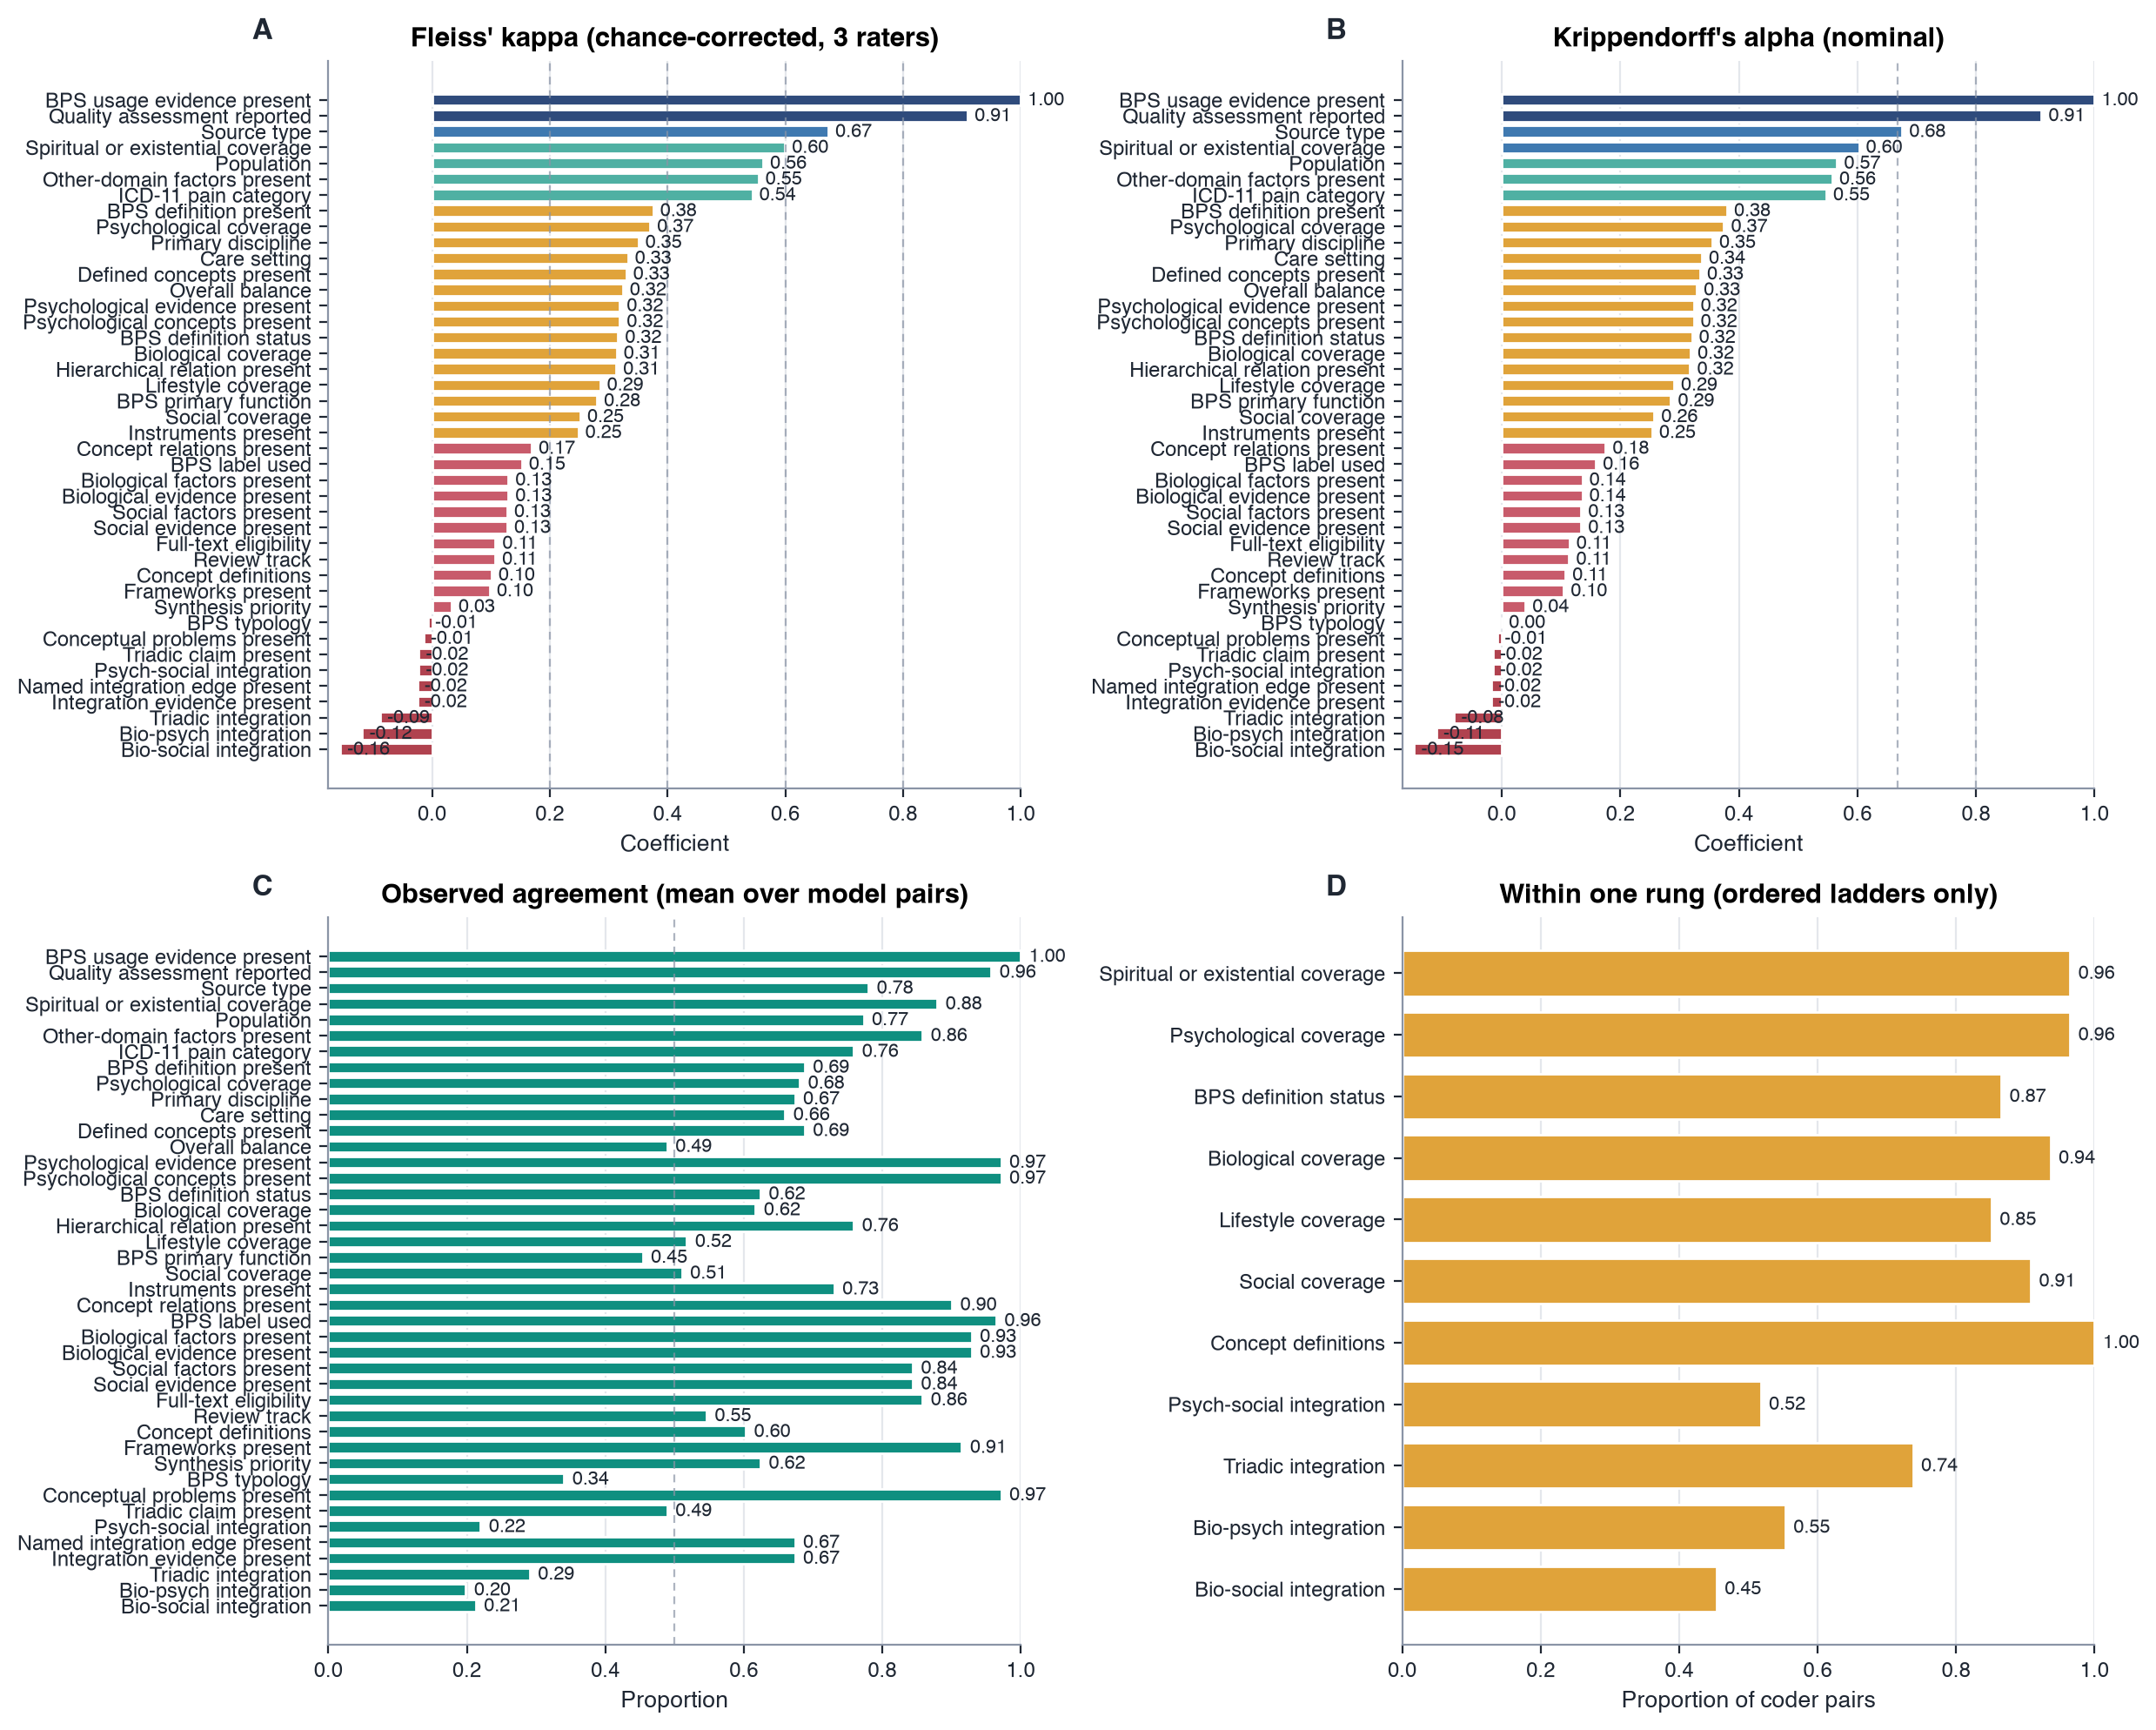

In [28]:
display(Image(filename=str(figures_dir() / "01_field_reliability_2x2.png")))

### Figure 2: agreement between providers, and the consensus typology

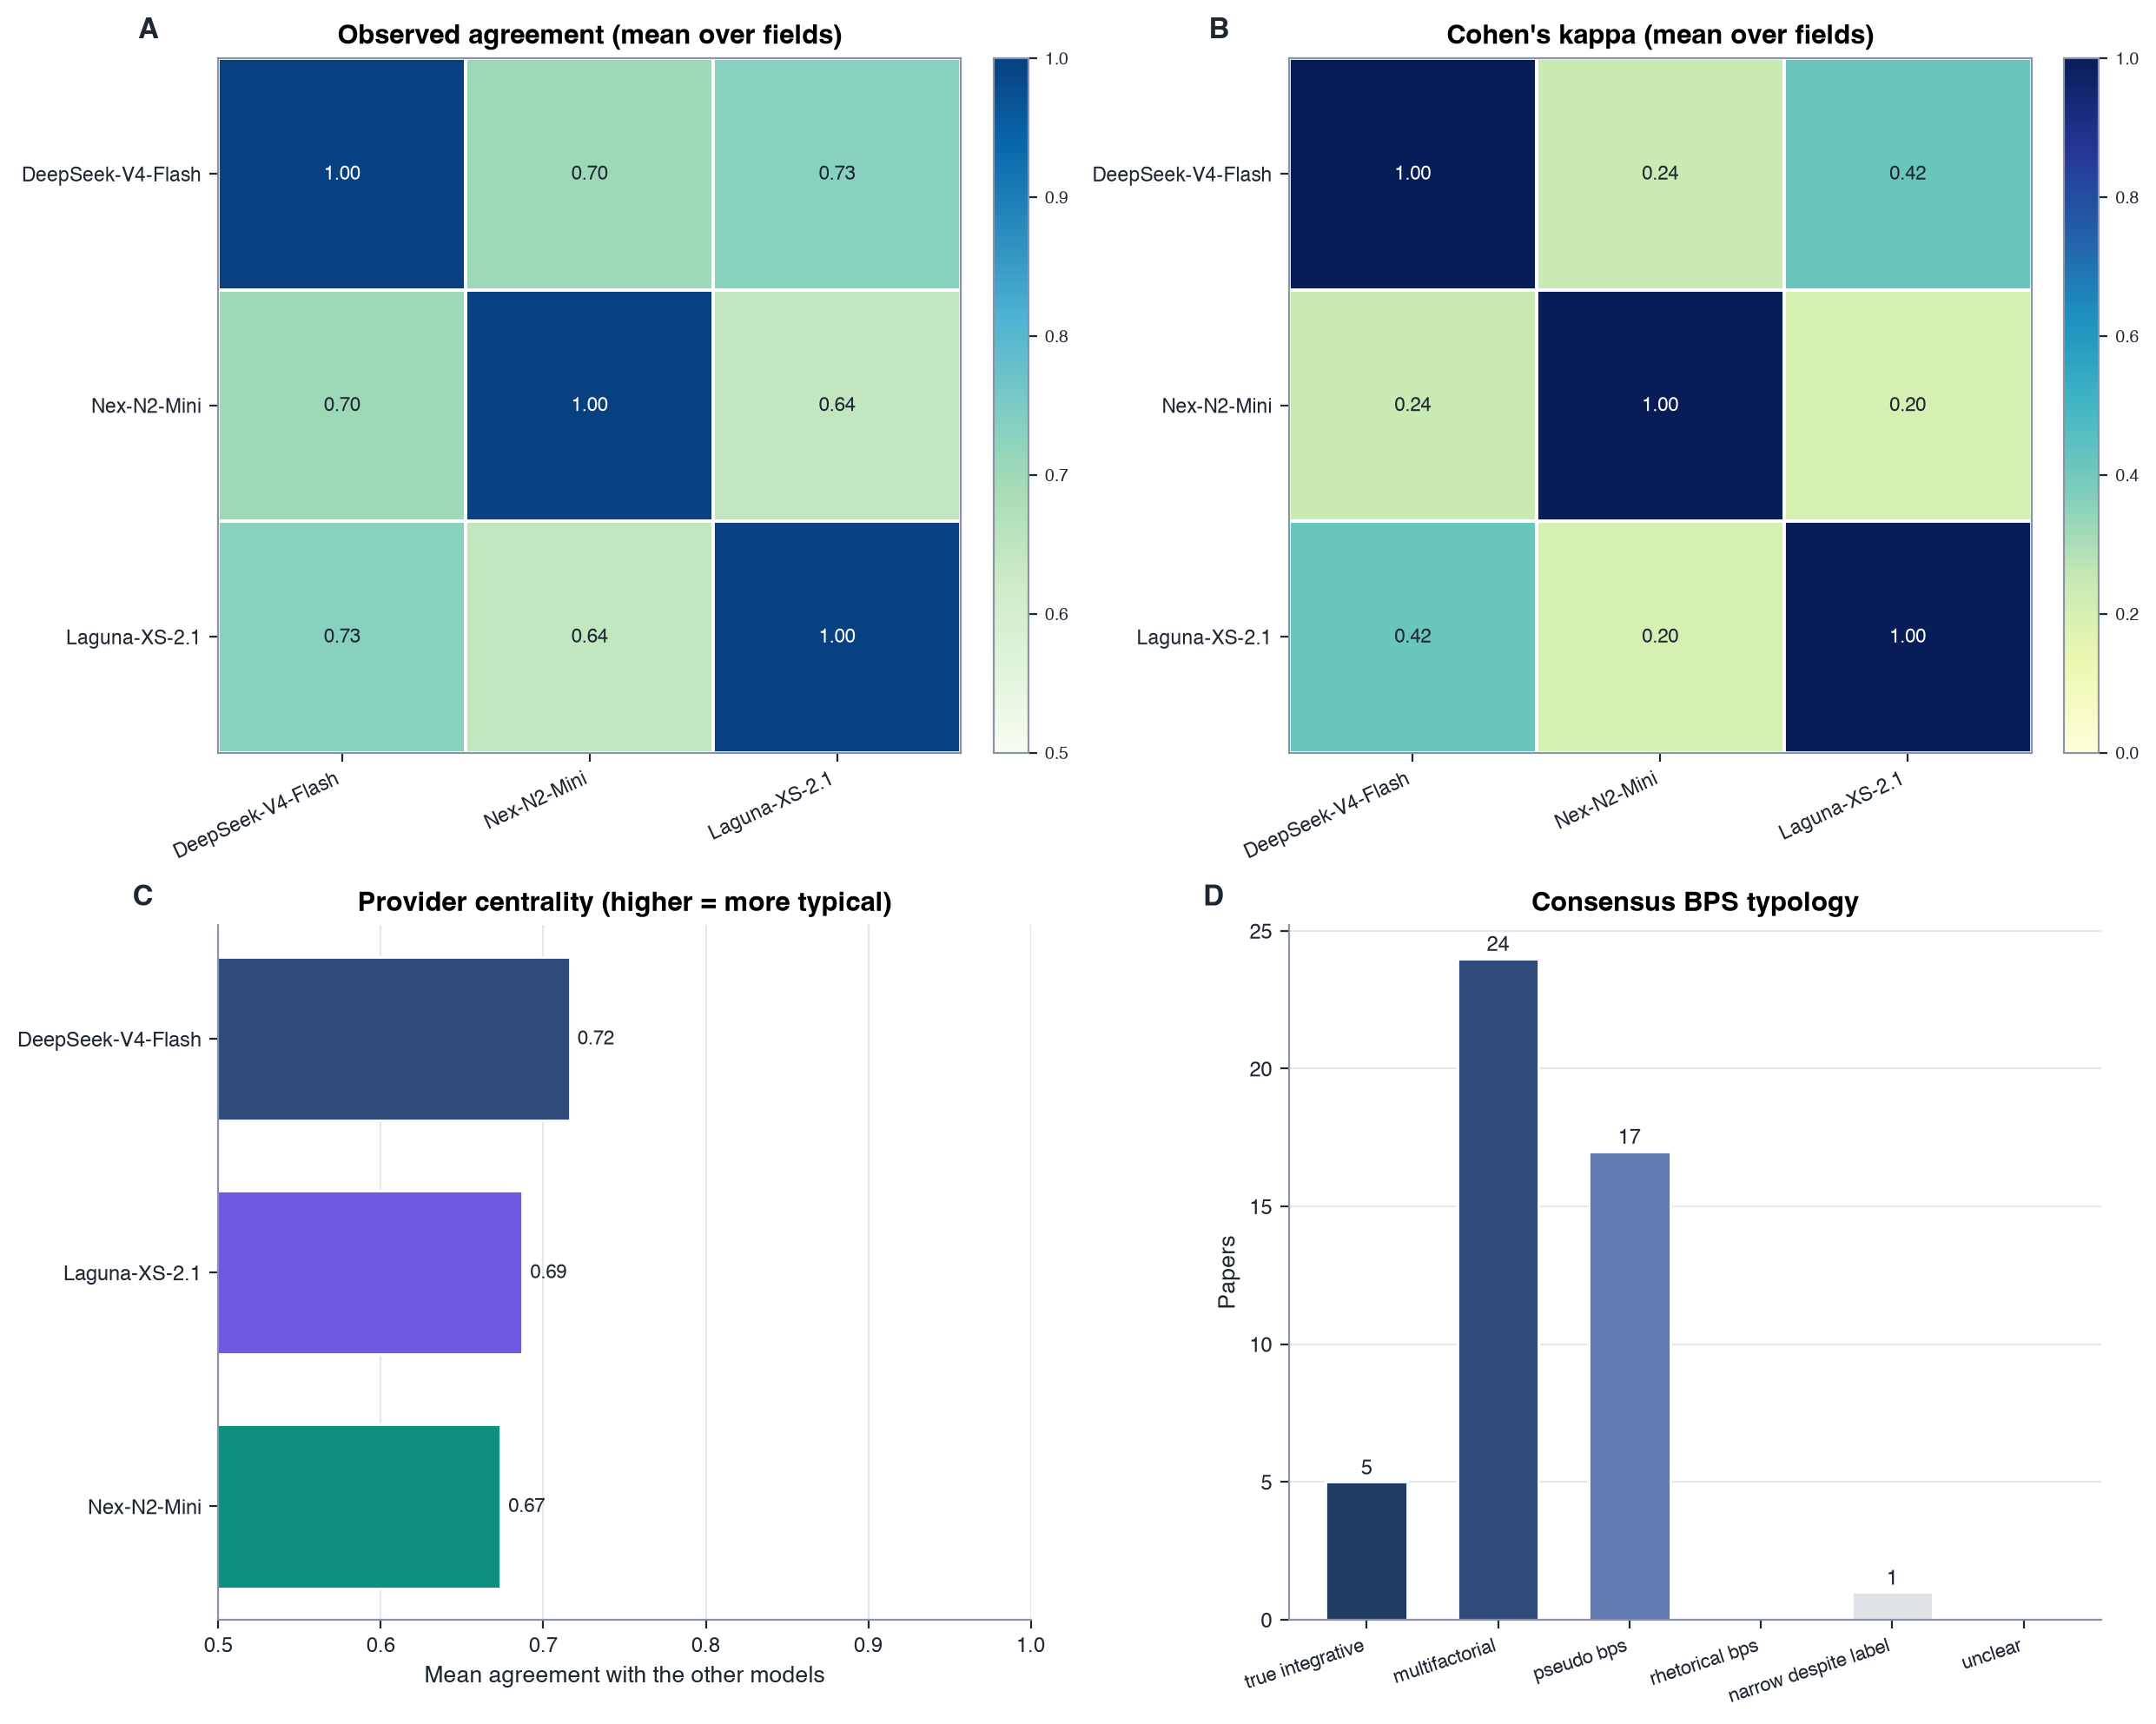

In [29]:
display(Image(filename=str(figures_dir() / "02_pairwise_and_consensus.png")))

### Figure 3: coverage and integration

Panels A and B are the corpus-level answer to the review's question, in consensus form: how
deeply each domain is covered, and how deeply each pair and the triad are integrated. Panel C
shows the same triadic judgement per model. Panel D is the integration index, one number per
coding, which makes the spread between the three readings visible.

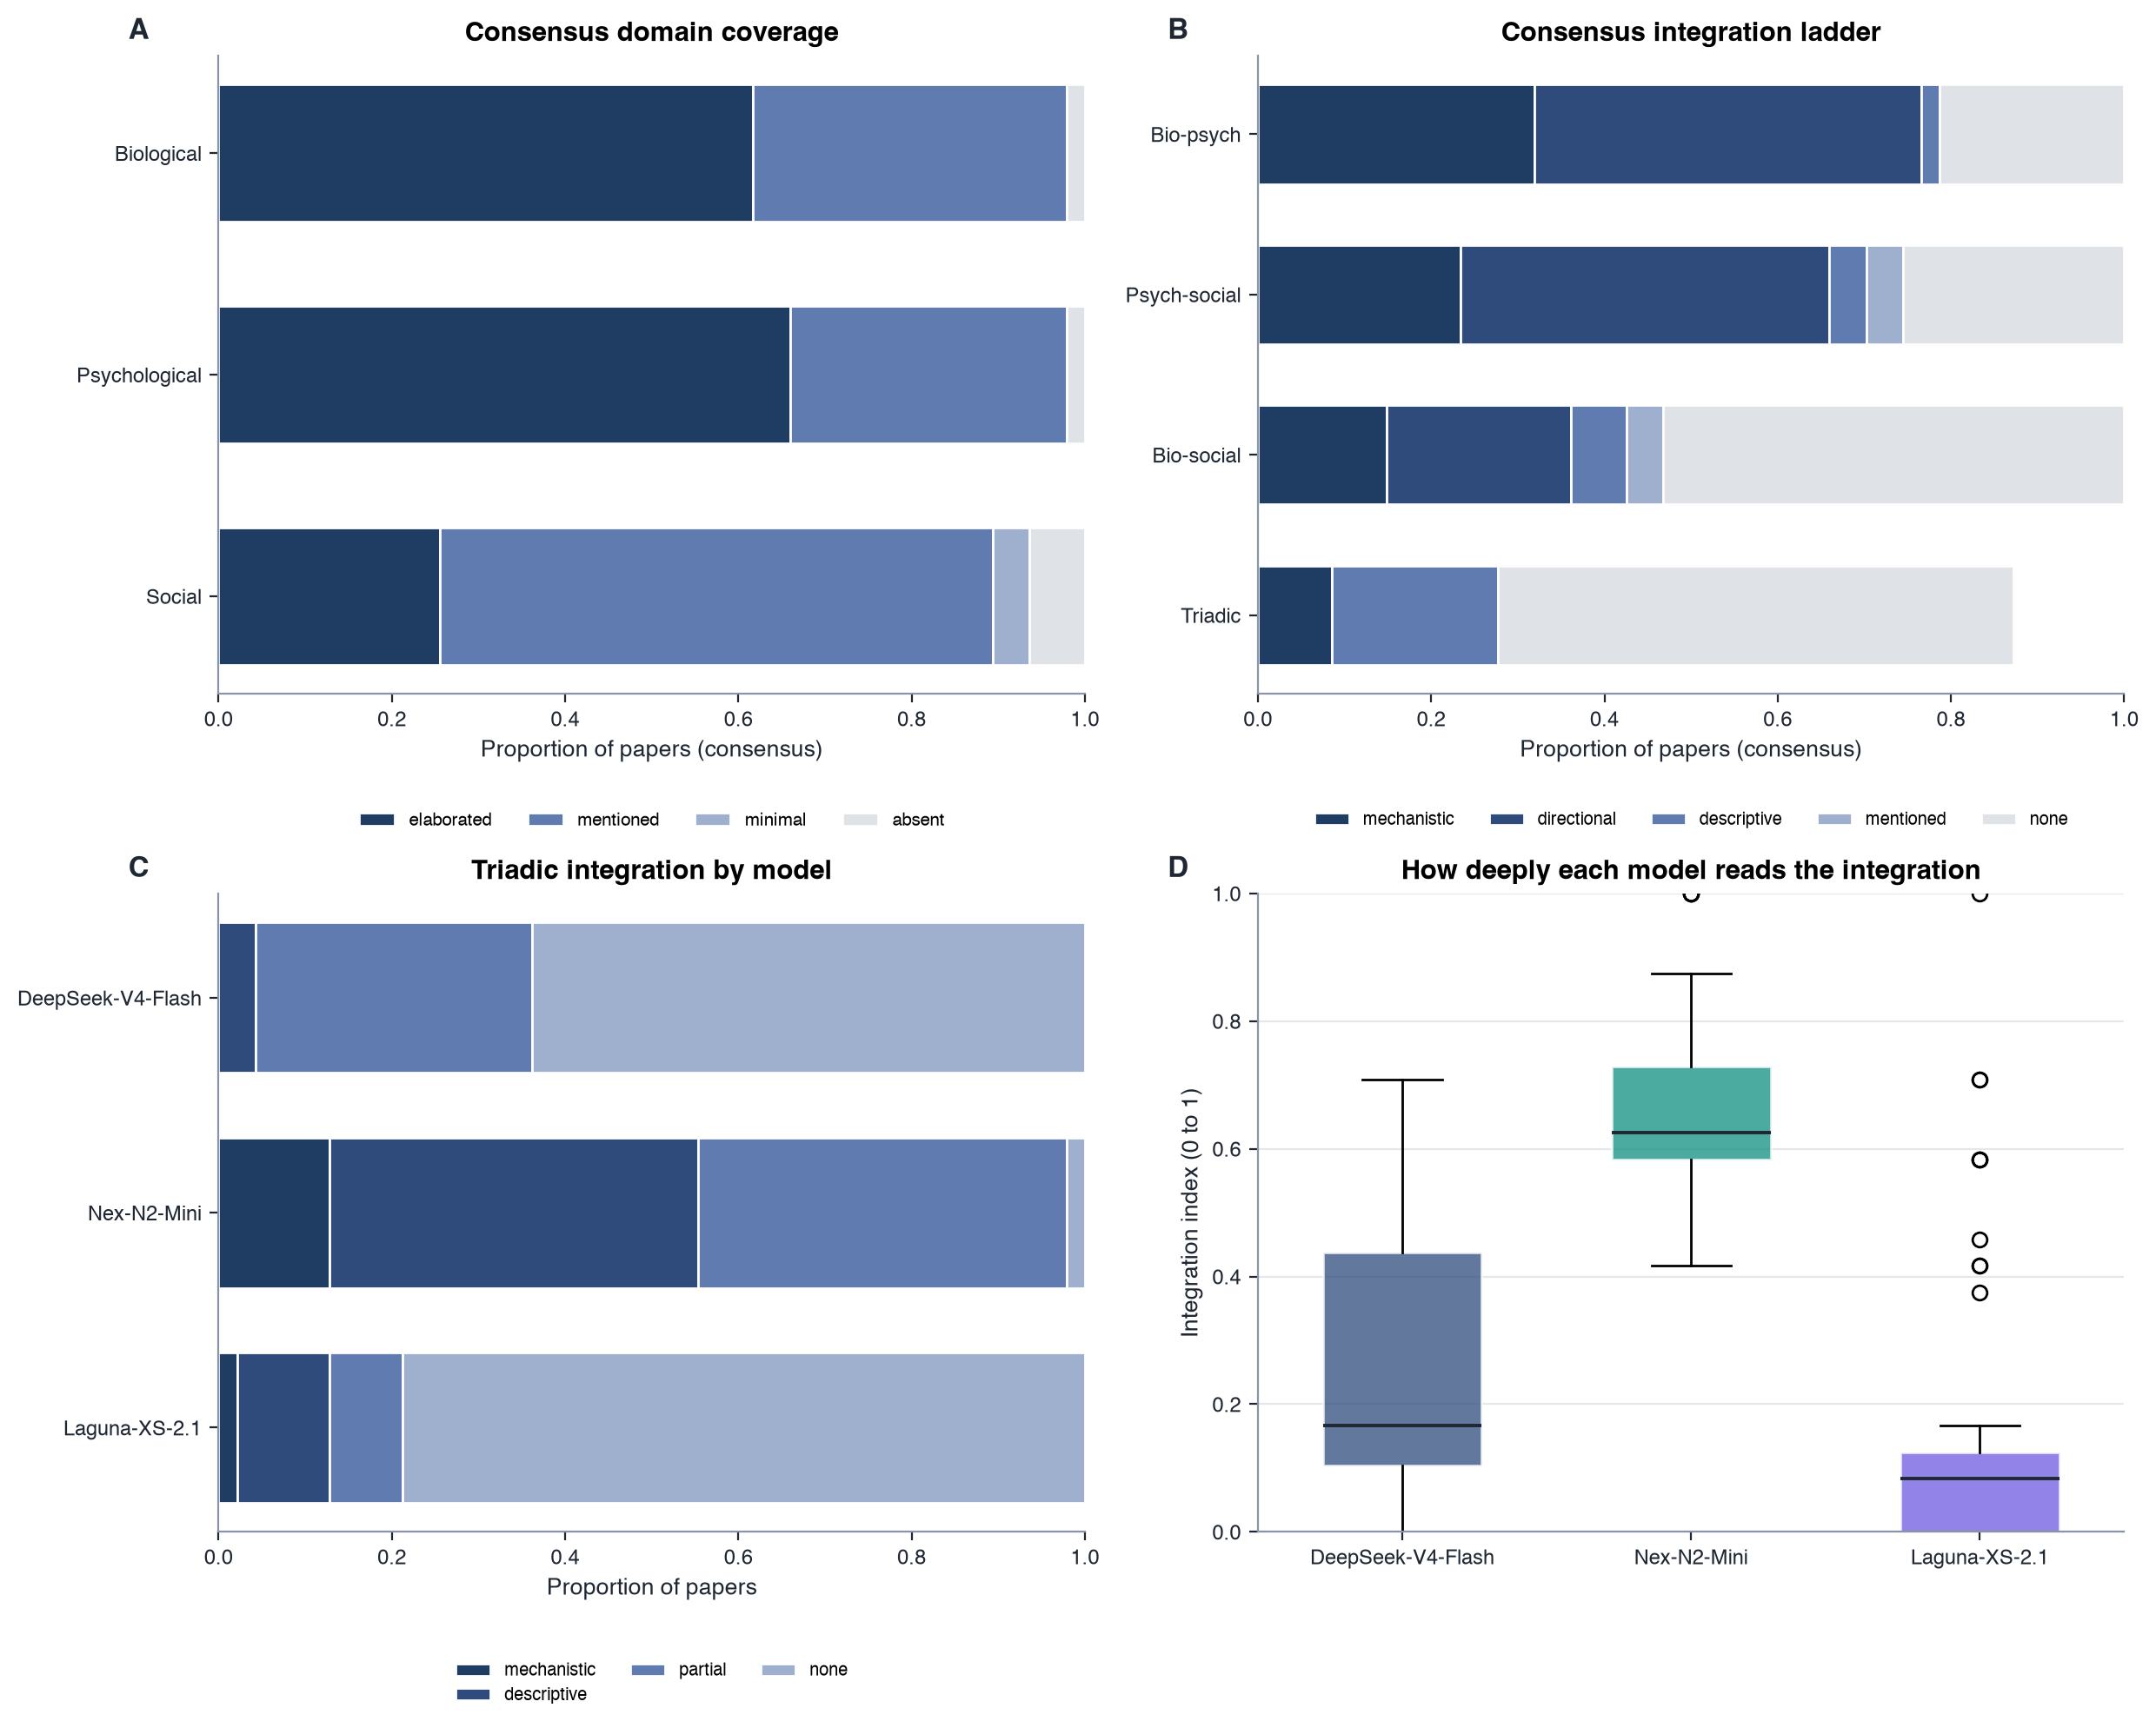

In [30]:
display(Image(filename=str(figures_dir() / "03_integration_profile.png")))

### Figure 4: evidence and yield

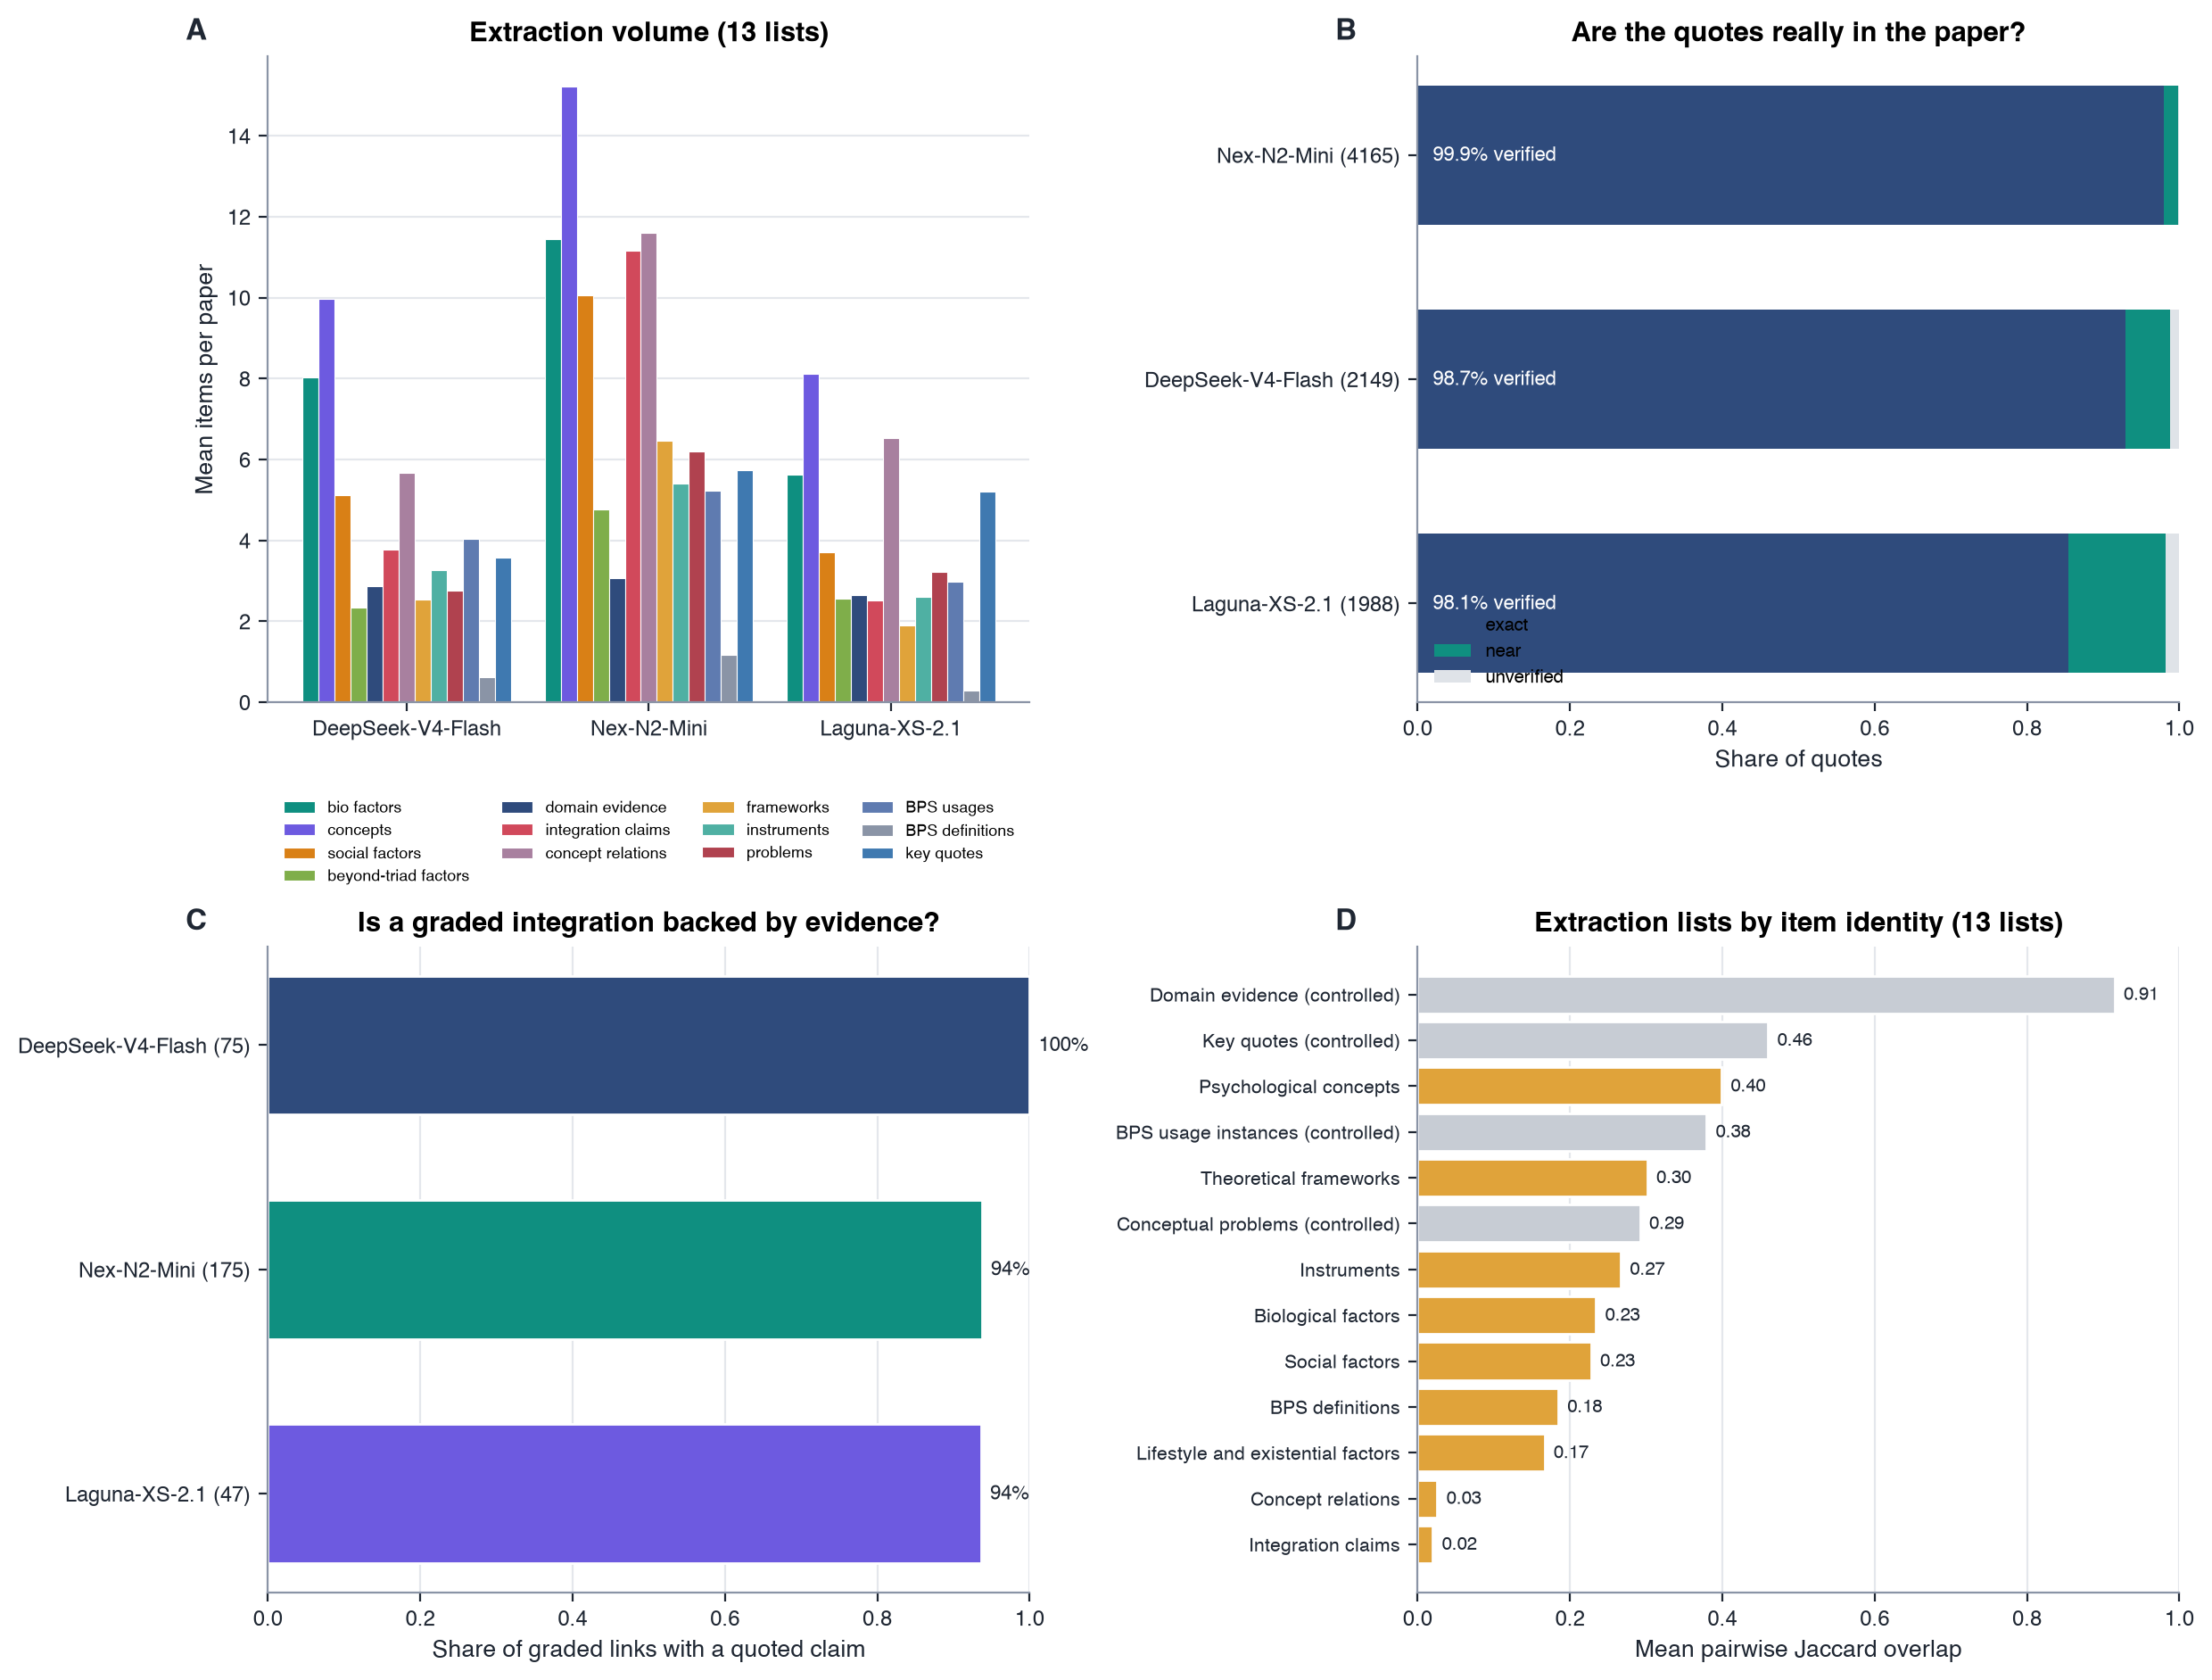

In [31]:
display(Image(filename=str(figures_dir() / "04_evidence_and_yield.png")))

### Figure 5: every comparable vocabulary, lexical against semantic


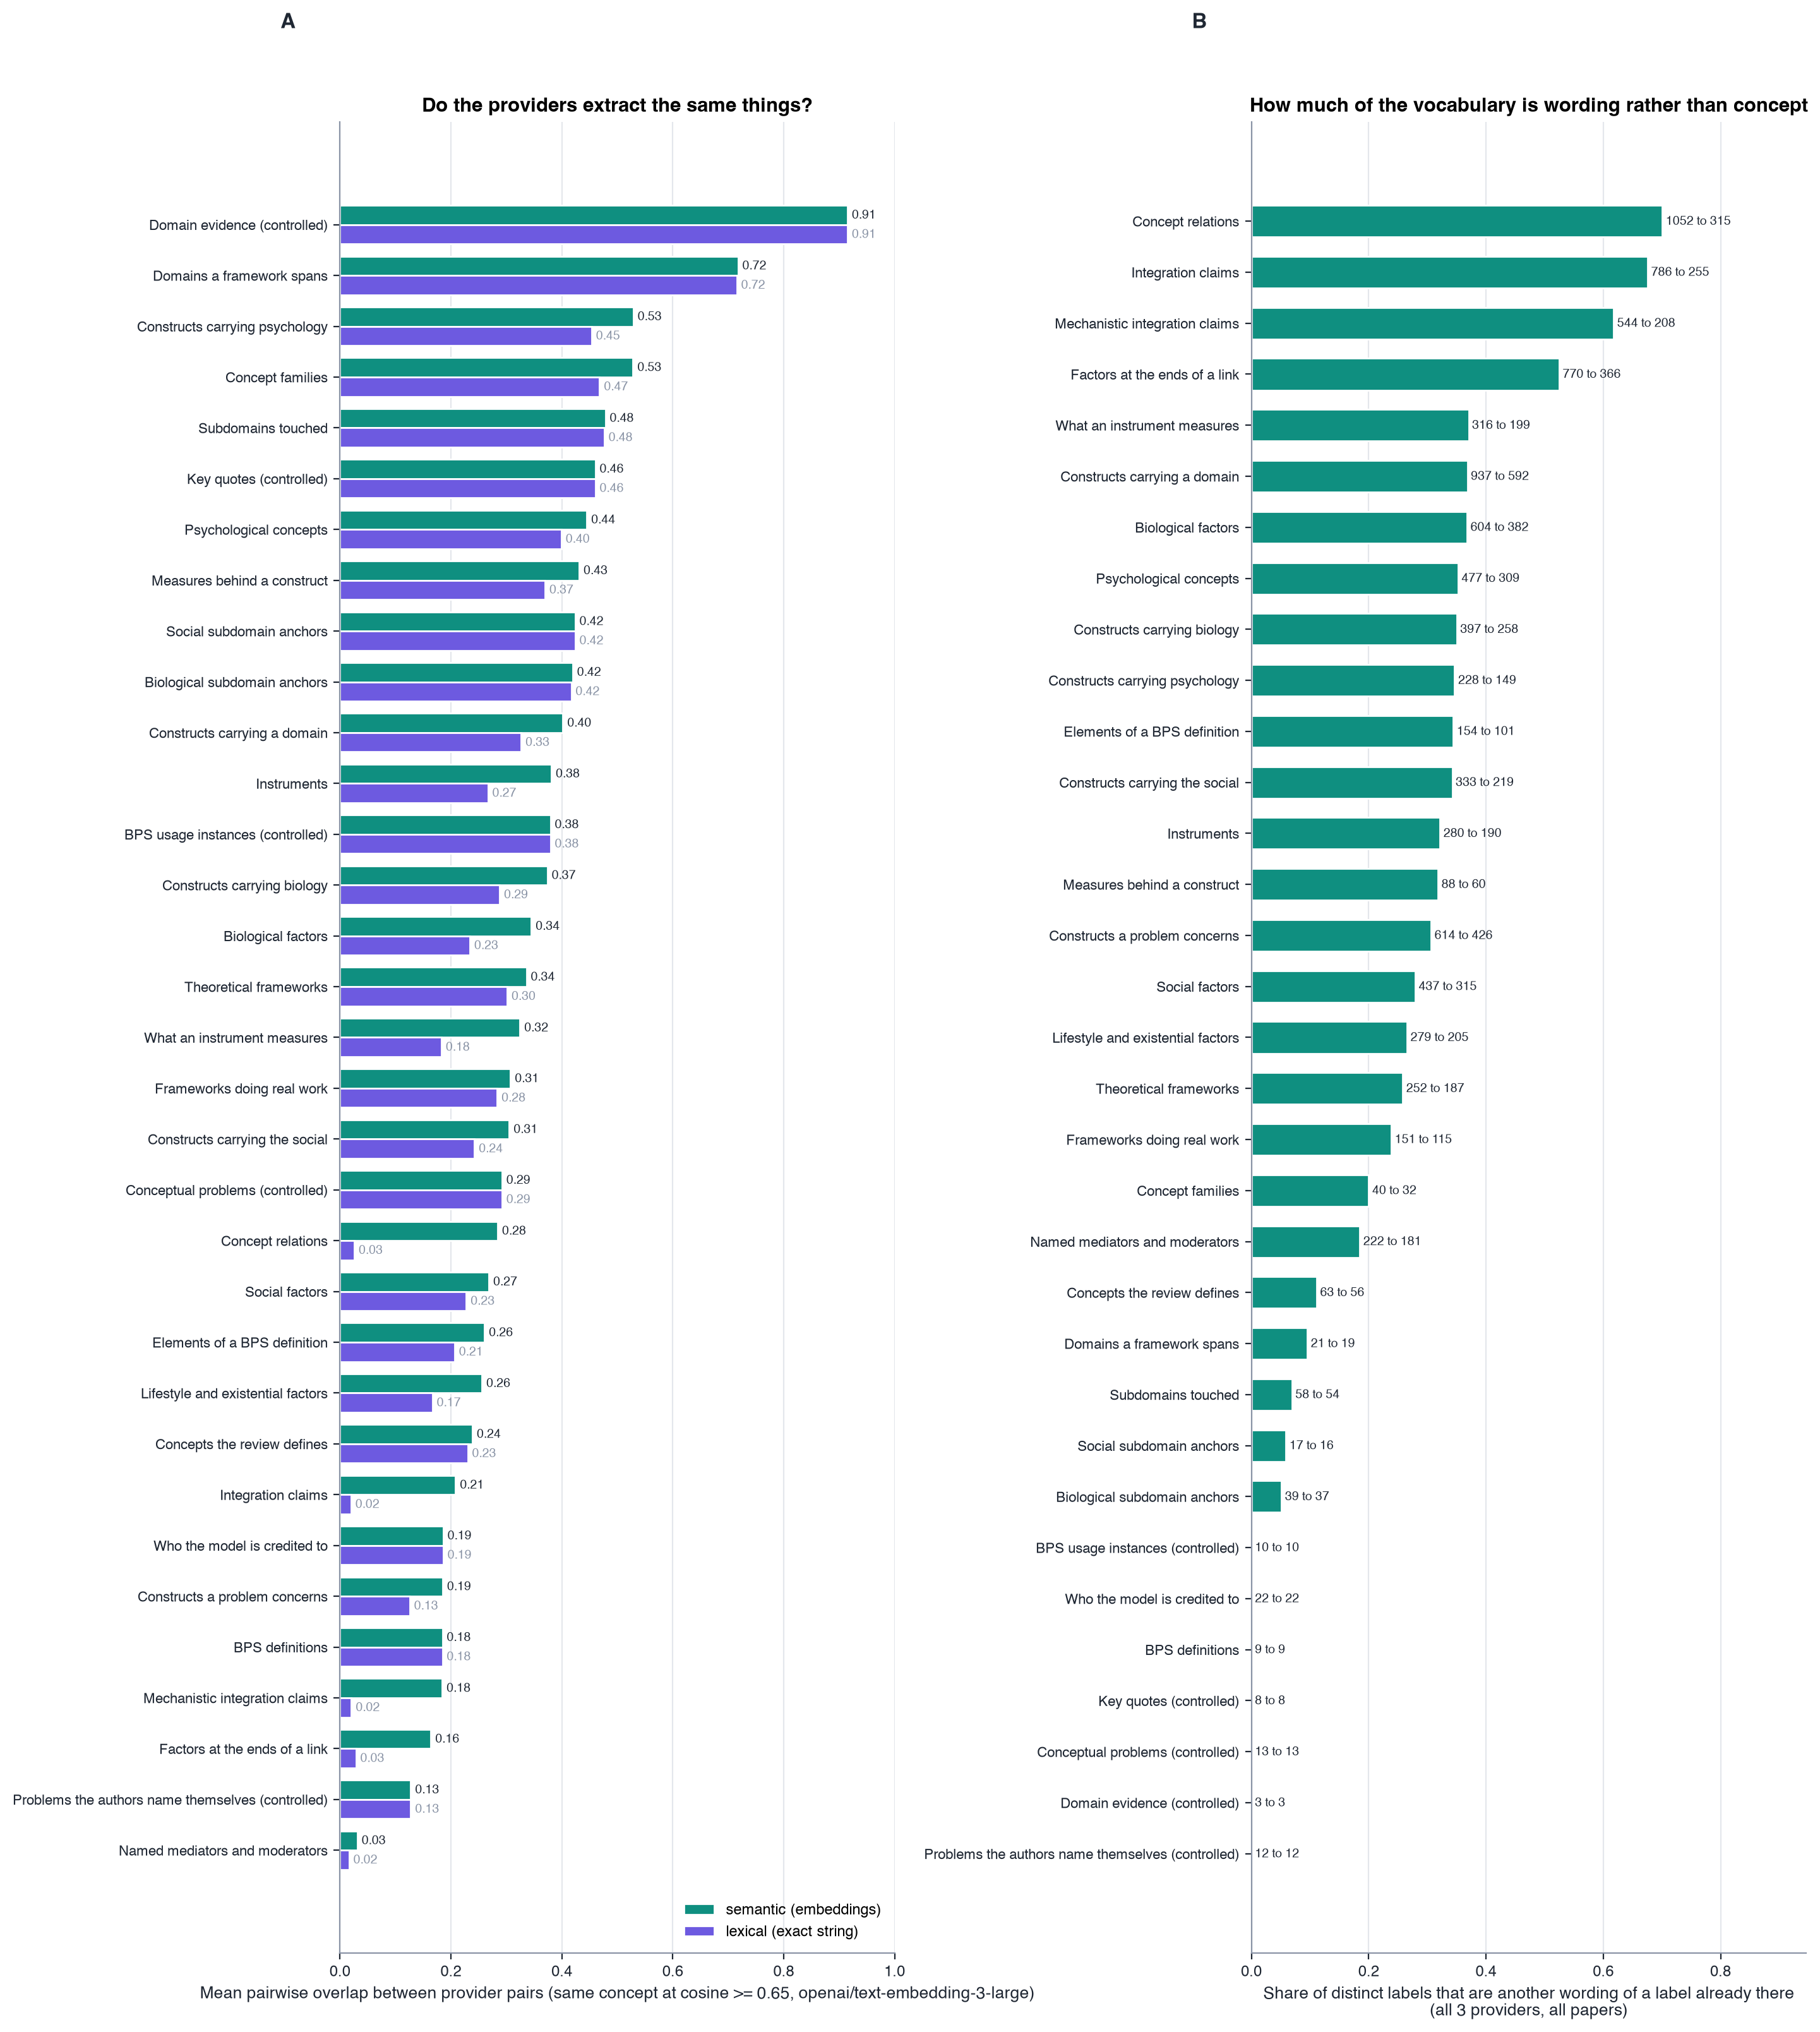

In [32]:
display(Image(filename=str(figures_dir() / "05_semantic_overlap.png")))


## 8. The typology, checked against itself

`bps_typology` is the scheme's summary verdict, and it is the field the review's argument rests
on. It is also the hardest to specify, because it compresses coverage and integration into one
label.

So the pipeline computes it twice. The coder codes it as the codebook describes, and the
pipeline independently derives `derived_typology` from the coverage and integration values by a
fixed rule. Their concordance is a direct test of whether the typology definition is tight
enough to be applied the same way twice. Where they diverge, the codebook is under-specified,
not the coder.

In [33]:
print(f"Coded typology matches the rule-derived typology in "
      f"{summary['typology_coded_matches_derived']:.1%} of codings.")
print()
concordance = results["typology_concordance"]
pivot = concordance.pivot(index="bps_typology", columns="derived_typology", values="n_codings").fillna(0).astype(int)
pivot

Coded typology matches the rule-derived typology in 53.2% of codings.



derived_typology,multifactorial,narrow_despite_label,pseudo_bps,rhetorical_bps,true_integrative
bps_typology,,,,,
multifactorial,35,0,11,0,15
narrow_despite_label,2,3,3,0,0
pseudo_bps,25,0,22,1,5
rhetorical_bps,0,1,1,1,0
true_integrative,2,0,0,0,14


In [34]:
per_model = (long_df.groupby("model_label")["typology_matches_derived"]
             .apply(lambda values: float((values == "yes").mean())).round(3))
print("Concordance between the coded and the derived typology, per model:")
print(per_model.to_string())

Concordance between the coded and the derived typology, per model:
model_label
DeepSeek-V4-Flash    0.596
Laguna-XS-2.1        0.617
Nex-N2-Mini          0.383


## 9. The consensus picture

What the corpus looks like once the three codings are collapsed by majority vote. These numbers
describe 47 open-access articles coded by three cheap models; they are a demonstration of what
the pipeline reports, not a result about the literature.

In [35]:
consensus = results["consensus"]
for field in list(COVERAGE_FIELDS) + list(INTEGRATION_FIELDS):
    counts = consensus[field].value_counts()
    line = ", ".join(f"{label} {count}" for label, count in counts.items())
    print(f"{FIELD_LABELS[field]:26s} {line}")
print()
print("BPS typology (consensus):")
print(consensus["bps_typology"].value_counts().to_string())
print()
print("Full-text eligibility (consensus):")
print(consensus["fulltext_eligibility"].value_counts().to_string())

Biological coverage        elaborated 29, mentioned 17, absent 1
Psychological coverage     elaborated 31, mentioned 15, absent 1
Social coverage            mentioned 30, elaborated 12, absent 3, minimal 2
Bio-psych integration      directional 21, mechanistic 15, none 10, descriptive 1
Psych-social integration   directional 20, none 12, mechanistic 11, descriptive 2, mentioned 2
Bio-social integration     none 25, directional 10, mechanistic 7, descriptive 3, mentioned 2
Triadic integration        none 28, descriptive 9, partial 6, mechanistic 4

BPS typology (consensus):
bps_typology
multifactorial          24
pseudo_bps              17
true_integrative         5
narrow_despite_label     1

Full-text eligibility (consensus):
fulltext_eligibility
include    46
exclude     1


### What the corpus talks about

The most frequently extracted concepts and frameworks across all three coders. This is a look at
what the corpus contains, not a synthesis: the actual synthesis happens later, on the screened
corpus, with the finalized schemes.

In [36]:
label_catalog(items_df, "psychological_concepts", top_n=15)

,label_normalized,n_extractions,n_papers,n_models
33,anxiety,129,43,3
131,depression,111,38,3
306,pain catastrophizing,108,36,3
446,stress,50,26,3
373,psychological distress,34,18,3
318,pain self-efficacy,48,16,3
388,quality of life,26,16,3
234,kinesiophobia,42,14,3
329,pain-related fear,20,12,3
467,treatment adherence,13,12,2


In [37]:
label_catalog(items_df, "theoretical_frameworks", top_n=12)

,label_normalized,n_extractions,n_papers,n_models
21,biopsychosocial model,109,44,3
76,fear-avoidance model,27,15,3
45,cognitive behavioural model,14,9,3
205,psychological flexibility model,12,9,2
86,gate control theory,9,4,3
16,biomedical model,5,4,2
152,neuromatrix theory,5,4,2
0,ICF framework,6,3,3
159,operant learning model,5,3,3
20,biopsychosocial approach,3,3,1


## 10. Cost, outputs, and takeaways

In [38]:
run_manifest = load_run_manifest()
usage = run_manifest["token_usage_total"]
print(f"Papers x models : {run_manifest['n_papers']} x {run_manifest['n_models']} = {run_manifest['n_codings']} codings")
print(f"Extracted items : {run_manifest['n_extracted_items']:,}")
print(f"Tokens          : {usage['total_tokens']:,} (of which {usage['reasoning_tokens']:,} reasoning)")
print(f"Cost            : ${usage['cost_usd']:.3f}")
print()
for label, values in run_manifest["token_usage_by_model"].items():
    print(f"  {label:20s} {values['total_tokens']:>10,} tokens   ${values['cost_usd']:.4f}")

Papers x models : 47 x 3 = 141 codings
Extracted items : 9,400
Tokens          : 5,133,914 (of which 1,006,031 reasoning)
Cost            : $0.335

  Laguna-XS-2.1         1,272,018 tokens   $0.0817
  DeepSeek-V4-Flash     1,233,817 tokens   $0.0849
  Nex-N2-Mini           2,628,079 tokens   $0.1684


In [ ]:
summary_text = write_fulltext_summary(long_df, results, integrity, corpus, semantic)

# The run is written as the tables it is read in: the citation and the DOI in front
# of every row, one column per list item, and one folder per extraction category.
published = build_output_tables(codings_dir(), long_df, items_df,
                                manifest=run_manifest, verbose=False)
print(f"{published['manifest']['n_coding_rows']} coding rows "
      f"x {published['manifest']['n_coding_columns']} columns, "
      f"{published['manifest']['n_extracted_items']:,} extracted items")
print()

base = ROOT / "src" / "05_test_runs" / "tests" / "02_pilot_fulltext"
for path in sorted(base.rglob("*")):
    if path.is_dir() or path.suffix not in {".csv", ".json", ".png", ".md", ".log", ".xlsx"}:
        continue
    depth = len(path.relative_to(base).parts)
    if depth <= 2:
        print(path.relative_to(base))
    elif path.name.startswith("01_"):
        print(f"{path.relative_to(base).parent}/ ...")


141 coding rows x 935 columns, 9,400 extracted items

01_corpus/README.md
01_corpus/articles.csv
01_corpus/corpus_manifest.json
01_corpus/papers.csv
01_corpus/retrieval_candidates.csv
01_corpus/retrieval_log.csv
02_model_codings/00_workbook.xlsx
02_model_codings/01_codings/ ...
02_model_codings/01_codings/04_the_same_rows_split_per_provider/ ...
02_model_codings/02_extracted_items/00_all_categories/ ...
02_model_codings/02_extracted_items/01_biological_factors/ ...
02_model_codings/02_extracted_items/02_psychological_concepts/ ...
02_model_codings/02_extracted_items/03_social_factors/ ...
02_model_codings/02_extracted_items/04_other_domain_factors/ ...
02_model_codings/02_extracted_items/05_domain_evidence/ ...
02_model_codings/02_extracted_items/06_integration_claims/ ...
02_model_codings/02_extracted_items/07_concept_relations/ ...
02_model_codings/02_extracted_items/08_bps_usage_instances/ ...
02_model_codings/02_extracted_items/09_bps_definitions/ ...
02_model_codings/02_extracted_

### The run as a knowledge graph

Everything above is a table. The same run is also a graph: run, field group, coding field,
provider, article coding, extracted item. That hierarchy is what a reviewer actually walks when
checking a judgement, because it ends at the sentence the judgement rests on.

The bundle is plain local HTML, CSS, and JavaScript. No server, no build step, no network. It
opens on the coding scheme itself, and the providers, papers, and extracted items are complete
descendants expanded on demand.


In [40]:
graph_report = export_fulltext_graph()
for key, value in graph_report.items():
    print(f"{key:16s} {value}")


  codings: 141, items: 9400, verified quotes: 8407
index            /Users/stijnvanseveren/PROJECTS/summer_2026/CROMBEZ_MAP/05_BPS_Review_Study/src/05_test_runs/tests/02_pilot_fulltext/05_knowledge_graph/index.html
papers           47
providers        3
codings          141
extracted_items  9400
quotes_verified  8407


Open `05_knowledge_graph/index.html` from the run directory in a desktop browser. Filter by
article, provider, or coding field; search every label, value, and quote; double-click a field to
drill into it; click any node for the full inspector, which shows the verbatim passage and
whether that passage was found in the source article.


### Takeaways

1. **The chain runs end to end.** A PubMed query, 100 abstracts coded by three providers, a
   consensus filter, open-access retrieval, and full-text coding of every retrieved paper by the
   same three providers, with no failed codings and for a cost measured in cents.

2. **Read the integrity numbers before the agreement numbers.** Quote verification and the
   evidence-discipline check answer a prior question: did the coder read the paper, and does its
   graded ladder point at a passage. Agreement between coders who are not reading the text would
   be worthless, however high.

3. **The integration ladder is where the scheme needs the most work.** Chance-corrected
   agreement on the four integration fields is close to zero while adjacent agreement is much
   higher: the coders land next to each other on the ladder rather than on it. Reading the two
   numbers together is what makes that diagnosable, and it points straight at the boundary
   rules between `mechanistic`, `directional`, and `descriptive`.

4. **The typology is where the scheme is loosest.** Both the between-coder agreement on
   `bps_typology` and its concordance with the rule-derived typology point at the same place:
   the value definitions compress too much into one label. That is the most actionable thing
   this run has to say to the expert evaluation.

5. **Extraction volume is not extraction quality.** The model that extracts the most items is
   not automatically the one whose quotes verify best. Both numbers are reported per model, and
   both belong in the choice of the state-of-the-art model for the real run.

**To reproduce**

```bash
python -m bps_review run-abstract-testrun --force-corpus --force-coding   # notebook 01
python -m bps_review build-fulltext-corpus                                # retrieval
python -m bps_review run-fulltext-testrun --force-coding                  # this notebook
```

The models are configured in `src/03_pipeline/bps_review/pilot/config.py` and reused here;
replacing them with state-of-the-art models is a single edit to `TESTRUN_MODELS`.